## Mars Photogrammetry Preprocessing Pipeline

By Christian Tate, Cornell University; Ithaca, NY

https://github.com/cdt59/MPPP


In [4]:
!pip install Metashape-2.1.0-cp37.cp38.cp39.cp310.cp311-none-win_amd64.whl


Processing c:\users\ongyi\compasse\calibration\mppp\metashape-2.1.0-cp37.cp38.cp39.cp310.cp311-none-win_amd64.whl


ERROR: Could not install packages due to an OSError: [Errno 2] No such file or directory: 'C:\\Users\\ongyi\\compasse\\Calibration\\MPPP\\Metashape-2.1.0-cp37.cp38.cp39.cp310.cp311-none-win_amd64.whl'



In [1]:
# Import python modules

import numpy as np
import cv2, glob, time, os
import matplotlib.pyplot as plt
from numpy.linalg import inv
from scipy import stats
# from planetaryimage import PDS3Image
# import colour_demosaicing
# from PIL import Image
# import matplotlib.cm as cm
# from scipy import interpolate
# from scipy.spatial.transform import Rotation as R
# import colour_demosaicing
import pandas as pd
from scipy.optimize import curve_fit

import Metashape
np.set_printoptions(suppress=True)

%run MPPP.py

%matplotlib inline

# directory_input  = 'Z:/Mastcam-Z/agisoft/data/cal'
# directory_input  = 'C:/Users/cdt59/Desktop/agisoft/data'
directory_input  = 'C:/Users/cdt59/Desktop/agisoft/data/cal'


ModuleNotFoundError: No module named 'Metashape'

In [2]:
doc = Metashape.Document( read_only=1 )

# doc.open(path="C:/Users/cdt59/Desktop/agisoft/m32_site_cal690_v2.psx")
# doc.open(path="Z:/Mastcam-Z/agisoft/jezero/m32_site_cal690_.psx")
# doc.open(path="Z:/Mastcam-Z/agisoft/jezero/m32_site_cal690_.psx")
# doc.open(path="C:/Users/cdt59/Desktop/agisoft/m41_site_cal_v202.psx")
# doc.open(path="C:/Users/cdt59/Desktop/agisoft/m41_site_cal_v4.psx")
# doc.open(path="C:/Users/cdt59/Desktop/agisoft/m41_site_cal_v217_.psx")
# doc.open(path="Z:/Mastcam-Z/agisoft/jezero/m41_site_cal_v217_v2_.psx")
# doc.open(path="Z:/Mastcam-Z/agisoft/jezero/m41_site_cal_v222_.psx")
# doc.open(path="C:/Users/cdt59/Desktop/agisoft/m41_site_cal_v224_.psx")
doc.open(path="C:/Users/cdt59/Desktop/agisoft/m41_site_cal_v229_.psx")

# path_references = "C:/Users/cdt59/Desktop/agisoft/m32_site_cal690_rnav_v2.txt"
# path_references = "C:/Users/cdt59/Desktop/agisoft/positions_refs_00_zcam_rnav.txt"
# path_references = "C:/Users/cdt59/Desktop/agisoft/positions_refs_00_zcam_rnav_v4.txt"
# path_references = "C:/Users/cdt59/Desktop/agisoft/positions_refs_00_zcam_rnav_v217.txt"
# path_references = "Z:/Mastcam-Z/agisoft/jezero/positions_refs_zcam_rnav_v217_v2.txt"
# path_references = "C:/Users/cdt59/Desktop/agisoft/m41_site_cal_v224_refs_v4.txt"

# df_r = pd.read_csv( path_references, skiprows=1 )
# df_r

version_name = 'm41_site_cal_v229_v2'

save_path =  '/plots/'+ version_name + '.xlsx'


In [3]:
%%time

%run MPPP.py

N_cams = len( doc.chunk.cameras )

columns = [ 'name', 'zcam', 'cam', 'fl', 
            'temp_DEA', 'temp_FPA', 
            'temp_HTR1', 'temp_HTR2', 
            'fmc', 'zmc', 'filtmc', 
            'az_RSM', 'el_RSM', 
            # 'cmod_r',
            'c_r','a_r','h_r','v_r','o_r','r_r',
            'c_r_est','a_r_est','h_r_est','v_r_est','o_r_est','r_r_est',
            'f_est','cx_est','cy_est','b1_est','b2_est',
            'k0_est','k1_est','k2_est','k3_est','k4_est','p1_est','p2_est',
            'f','cx','cy','b1','b2',
            'k0', 'k1','k2','k3','k4','p1','p2',
            'w','h',
            'X_ref','Y_ref','Z_ref','X_est','Y_est','Z_est',
            'KnKR_e_c_est',
            'q_rpm', 'R_rpm', 't_rpm',
            'cahvor_r', 'cahvor_r_est'
            ]
ls = []


for i in range( N_cams )[::-1]:
    
    if doc.chunk.cameras[ i ].enabled:

        
        if doc.chunk.cameras[ i ].label[:1] == 'Z' or doc.chunk.cameras[ i ].label[45:48] == '034':

            cam = doc.chunk.cameras[ i ]
            
            IMG_path = glob.glob( directory_input + '/zcam/*/' + cam.label[:54] + '.IMG' ) + glob.glob( directory_input + '/zcam/' + cam.label[:54] + '.IMG' )

            # if 'ZCAM07221_0630LMA' in cam.label:
            #     IMG_path = glob.glob( directory_input + '/zcam/*/' + cam.label[:54] + '.IMG' ) + glob.glob( directory_input + '/zcam/' + cam.label[:34] + '*ZCAM07221_063085A*' + '.IMG' )
            #     print( 'replacing LM with 85')
            
            if len(IMG_path) and cam.transform and cam.reference.enabled:

                print( i, cam)

                # print( doc.chunk.cameras[ i ].label)

                im = image( IMG_path[0] )

                zcam = cam.label[1:2] == 'R'
                cam_ = cam.label[:2] + cam.label[45:48]
                fl   = int( cam.label[45:48] )


                T_chunk = np.array( doc.chunk.transform.matrix   ).reshape((4,4))
                R_chunk = np.array( doc.chunk.transform.rotation ).reshape((3,3))

                T_cam  = np.array( cam.transform).reshape((4,4))
                R_cam  = T_cam[:3,:3]

                T_world = T_chunk @ T_cam 
                T_world[:3,:3]   /= doc.chunk.transform.scale
                t_world = T_world[:3,3]
                R_world = R_chunk @ R_cam

                R_site2ned  = np.array( [[0,1,0],[1,0,0],[0,0,-1]] ) 

                KnKR_est_ = inv(R_world) @ R_site2ned 
                t_est     = t_world
                t_ref     = np.array(cam.reference.location)

                q_RM = q_wxyz2xyzw( im.label['GEOMETRIC_CAMERA_MODEL']['MODEL_TRANSFORM_QUATERNION'] )
                R_RM = R.from_quat( q_RM ).as_matrix()
                t_RM = im.label['GEOMETRIC_CAMERA_MODEL']['MODEL_TRANSFORM_VECTOR']


                c_r = im.label['GEOMETRIC_CAMERA_MODEL']['MODEL_COMPONENT_1']
                a_r = im.label['GEOMETRIC_CAMERA_MODEL']['MODEL_COMPONENT_2']
                h_r = im.label['GEOMETRIC_CAMERA_MODEL']['MODEL_COMPONENT_3']
                v_r = im.label['GEOMETRIC_CAMERA_MODEL']['MODEL_COMPONENT_4']
                o_r = im.label['GEOMETRIC_CAMERA_MODEL']['MODEL_COMPONENT_5']
                r_r = im.label['GEOMETRIC_CAMERA_MODEL']['MODEL_COMPONENT_6']
                cahvor_r = cahvor_combine(c_r,a_r,h_r,v_r,o_r,r_r)

                cahvor_r_est = cmod_cahvor_from_MS( t_est[1], t_est[0], -t_est[2], KnKR_est_, 
                                                    cam.calibration.f, cam.calibration.cx, cam.calibration.cy, cam.calibration.b1, cam.calibration.b2, 0, cam.calibration.k1, cam.calibration.k2  )
                # cahvor_r_est = cmod_transform_cahvor( cahvor_e_est, np.eye(3), np.array([0,0,0]) )
                c_r_est, a_r_est, h_r_est, v_r_est, o_r_est, r_r_est = cahvor_seperate(cahvor_r_est)

                X, Y, Z, Rot, f, cx, cy, b1, b2, k0, k1, k2 = cmod_MS_from_cahvor_PDS( im.label['GEOMETRIC_CAMERA_MODEL'] )

                l = [cam.label, zcam, cam_, fl,
                im.label['INSTRUMENT_STATE_PARMS']['INSTRUMENT_TEMPERATURE'][0], im.label['INSTRUMENT_STATE_PARMS']['INSTRUMENT_TEMPERATURE'][1], 
                im.label['INSTRUMENT_STATE_PARMS']['INSTRUMENT_TEMPERATURE'][2], im.label['INSTRUMENT_STATE_PARMS']['INSTRUMENT_TEMPERATURE'][3], 
                im.focus_mc, im.zoom_mc, im.filt_mc, 
                im.label['RSM_ARTICULATION_STATE']['ARTICULATION_DEVICE_ANGLE'][0], im.label['RSM_ARTICULATION_STATE']['ARTICULATION_DEVICE_ANGLE'][1],
                # im.label['GEOMETRIC_CAMERA_MODEL'], 
                c_r, a_r, h_r, v_r, o_r, r_r,
                c_r_est, a_r_est, h_r_est, v_r_est, o_r_est, r_r_est,
                cam.calibration.f, cam.calibration.cx, cam.calibration.cy, cam.calibration.b1, cam.calibration.b2, 
                0, cam.calibration.k1, cam.calibration.k2, cam.calibration.k3, cam.calibration.k4, cam.calibration.p1, cam.calibration.p2, 
                f, cx, cy, b1, b2, 
                k0, k1, k2, 0, 0, 0, 0, 
                cam.calibration.width,cam.calibration.height,
                t_ref[0], t_ref[1], t_ref[2], t_est[0], t_est[1], t_est[2],
                KnKR_est_,
                q_RM, R_RM, t_RM,
                cahvor_r, cahvor_r_est]

                ls.append( l )


        # if doc.chunk.cameras[ i ].label[:1] == 'N' or doc.chunk.cameras[ i ].label[:1] == 'F':
            
        #     cam = doc.chunk.cameras[ i ]
            
        #     IMG_path      = [] 
        #     IMG_path     += sorted( glob.glob(  directory_input + '/datadrive/' +cam.label[:54]+'.IMG' ) ) 
        #     IMG_path     += sorted( glob.glob(  directory_input + '/datadrive/*/ids/rdr/*/' +cam.label[:54]+'.IMG' ) ) 
            
        #     if len(IMG_path):

        #         print( doc.chunk.cameras[ i ].label)

        #         im = image( IMG_path[0], just_label=1 )

        #         l = [ cam.label, -1, -1, -1, im.label['GEOMETRIC_CAMERA_MODEL'], 
        #         cam.transform, cam.calibration.f, cam.calibration.cx, cam.calibration.cy, cam.calibration.b1, cam.calibration.b2, 
        #         cam.calibration.k1, cam.calibration.k2, cam.calibration.k3, cam.calibration.k4, cam.calibration.p1, cam.calibration.p2, cam.calibration.width,cam.calibration.height]
        #         ls.append( l )

df = pd.DataFrame(ls, columns = columns )

df

42551 <Camera 'ZR0_0962_0752335289_144RAD_N0470000ZCAM08986_1100LMA02'>
42550 <Camera 'ZR0_0962_0752335276_150RAD_N0470000ZCAM08986_1100LMA02'>
42549 <Camera 'ZR0_0962_0752334464_144RAD_N0470000ZCAM08986_1100LMA02'>
42066 <Camera 'ZL0_0962_0752334150_144RAD_N0470000ZCAM08986_1100LMA01'>
41978 <Camera 'ZR0_0991_0754913683_706RAD_N0470000ZCAM08992_1100LMA01'>
41977 <Camera 'ZR0_0991_0754912563_943RAD_N0470000ZCAM03823_1100LMA01'>
41976 <Camera 'ZR0_0991_0754912196_832RAD_N0470000ZCAM03822_1100LMA01'>
41975 <Camera 'ZR0_0991_0754899352_488RAD_N0470000ZCAM08992_1100LMA01'>
41974 <Camera 'ZR0_0990_0754844364_098RAD_N0470000ZCAM08992_1100LMA03'>
41973 <Camera 'ZR0_0990_0754837704_928RAD_N0470000ZCAM08992_1100LMA01'>
41972 <Camera 'ZR0_0990_0754824797_568RAD_N0470000ZCAM08992_1100LMA01'>
41971 <Camera 'ZR0_0990_0754810578_098RAD_N0470000ZCAM08992_1100LMA01'>
41970 <Camera 'ZR0_0989_0754755619_081RAD_N0470000ZCAM08992_1100LMA01'>
41969 <Camera 'ZR0_0989_0754749546_098RAD_N0470000ZCAM08992_1100

,name,zcam,cam,fl,temp_DEA,temp_FPA,temp_HTR1,temp_HTR2,fmc,zmc,...,Z_ref,X_est,Y_est,Z_est,KnKR_e_c_est,q_rpm,R_rpm,t_rpm,cahvor_r,cahvor_r_est
0,ZR0_0962_0752335289_144RAD_N0470000ZCAM08986_1...,True,ZR110,110,28.2055,-11.44810,-14.89650,-14.7788,3078,9600,...,1.98490,0.661395,0.884563,1.983466,"[[0.356328113365, 0.934324953061, 0.0081949810...","[-3.53962e-05, -0.00129324, -0.170709, 0.985321]","[[0.94171357105, 0.336406178068, -0.0025364263...","[0.805031, 0.559419, -1.91903]","[0.865343, 0.664932, -1.98492, 0.935733, -0.35...","[0.884562788016, 0.661394814328, -1.9834656513..."
1,ZR0_0962_0752335276_150RAD_N0470000ZCAM08986_1...,True,ZR110,110,28.2055,-11.44810,-14.89650,-14.7788,3078,9600,...,1.98485,0.648508,0.894658,1.985454,"[[0.437037704826, 0.899404843897, 0.0083048981...","[-0.000201611, -0.00196711, -0.21389, 0.976856]","[[0.90849444132, 0.417880049352, -0.0037569194...","[0.805029, 0.559413, -1.91903]","[0.874466, 0.659184, -1.98489, 0.901113, -0.43...","[0.894657730105, 0.648507786217, -1.9854536986..."
2,ZR0_0962_0752334464_144RAD_N0470000ZCAM08986_1...,True,ZR110,110,0.0000,-13.34860,-15.53870,-16.3658,3108,9600,...,1.98709,0.683220,0.785725,1.985711,"[[-0.36930973211, 0.92929668092, 0.00424271135...","[-0.00682429, 0.0327488, 0.198649, 0.9795]","[[0.918932240978, -0.389600081194, 0.061443577...","[0.80503, 0.55947, -1.91903]","[0.773458, 0.675983, -1.98631, 0.9262, 0.37293...","[0.785724524395, 0.683220141635, -1.9857114843..."
3,ZL0_0962_0752334150_144RAD_N0470000ZCAM08986_1...,False,ZL110,110,23.9058,-13.12520,-16.05420,-15.5843,3186,9600,...,1.98788,0.430356,0.782404,1.987408,"[[0.390839454358, 0.920457875578, -0.001349149...","[0.00700606, 0.0312862, -0.209013, 0.977387]","[[0.910669451628, 0.409011689566, 0.0582287529...","[0.805029, 0.559414, -1.91903]","[0.76772, 0.440274, -1.98603, 0.916645, -0.396...","[0.782404213947, 0.430355575353, -1.9874077697..."
4,ZR0_0991_0754913683_706RAD_N0470000ZCAM08992_1...,True,ZR110,110,0.0000,-9.54616,-9.75273,-10.6477,2316,9600,...,1.94335,0.670527,0.898549,1.937298,"[[0.165450685172, 0.985959300301, 0.0225904609...","[-0.0302059, -0.378879, -0.071575, 0.92218]","[[0.702655631624, 0.154898732396, -0.694464863...","[0.805034, 0.559432, -1.91903]","[0.88548, 0.668161, -1.95088, 0.702254, -0.119...","[0.89854900735, 0.670526652967, -1.93729841495..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3679,ZL0_0023_0668982318_910RAD_N0030770ZCAM03003_0...,False,ZL048,48,26.1888,-23.01850,-26.93010,-26.4921,486,3834,...,1.96601,0.671455,0.738290,1.968581,"[[0.247165809658, -0.968748358679, -0.02087295...","[-0.271075, -0.0298489, -0.955852, 0.10943]","[[-0.829086938637, 0.2253802184, 0.51168213310...","[0.804898, 0.559427, -1.91903]","[0.728877, 0.669528, -1.96571, -0.824774, -0.2...","[0.738290068245, 0.671455368217, -1.9685805167..."
3680,ZL0_0023_0668982227_910RAD_N0030770ZCAM03003_0...,False,ZL034,34,25.8625,-23.33710,-27.24930,-26.8122,-612,2448,...,1.95785,0.677650,0.738950,1.964280,"[[0.147908038895, -0.98881077045, -0.019402893...","[-0.254109, -0.0151535, -0.965059, 0.0621242]","[[-0.863138304278, 0.12760840717, 0.4885778976...","[0.804896, 0.559434, -1.91903]","[0.726497, 0.6744, -1.95836, -0.859796, -0.138...","[0.738949666002, 0.677649580987, -1.9642804669..."
3681,ZL0_0023_0668982137_910RAD_N0030770ZCAM03003_0...,False,ZL034,34,25.5363,-23.97400,-27.56840,-27.1323,-612,2448,...,1.95553,0.668254,0.722895,1.959735,"[[0.244219366291, -0.96952395562, -0.019498733...","[-0.271087, -0.0298404, -0.955852, 0.109395]","[[-0.829088960736, 0.225309790775, 0.511709872...","[0.804898, 0.559427, -1.91903]","[0.714078, 0.665721, -1.95597, -0.823196, -0.2...","[0.722894845146, 0.668254261994, -1.9597353241..."
3682,ZL0_0023_0668982043_910RAD_N0030770ZCAM03003_0...,False,ZL026,26,24.8840,-24.61070,-27.56840,-27.4523,-1866,504,...,1.95320,0.676620,0.725800,1.956322,"[[0.144423444922, -0.989360363149, -0.01754823...","[-0.252247, -0.015029, 

In [6]:

# df.to_excel('plots/'+ version_name + '_Z034.xlsx')
df.to_excel('plots/'+ version_name + '.xlsx')


AttributeError: 'Metashape.Metashape.Camera' object has no attribute 'location'

In [5]:
cam.label[45:48]

'110'

3529

In [ ]:
%run MPPP.py

N_cams = df.shape[0]

df['fmc_ref']   = np.nan
 
df['filt']      = np.nan
df['filt_ref']  = np.nan

# df['X'] = np.nan
# df['Y'] = np.nan
# df['Z'] = np.nan

# df['f']  = np.nan
# df['cx'] = np.nan
# df['cy'] = np.nan
# df['b1'] = np.nan
# df['b2'] = np.nan
# df['k0'] = np.nan
# df['k1'] = np.nan
# df['k2'] = np.nan
# df['k3'] = np.nan
# df['p1'] = np.nan
# df['p2'] = np.nan

# df['az_center'] = np.nan
# df['el_center'] = np.nan
# df['rl_center'] = np.nan
# df['az_center_est'] = np.nan
# df['el_center_est'] = np.nan
# df['rl_center_est'] = np.nan



# df['rayc']  = None
# df['rayc_est'] = None

df['valid'] = True

# df['cmod_est']     = df['cmod'].copy()

# df['q_i']   = np.nan
# df['q_j']   = np.nan
# df['q_k']   = np.nan
# df['q_w']   = np.nan
# df['v_i']   = np.nan
# df['v_j']   = np.nan
# df['v_k']   = np.nan

# df['q_i_est']   = np.nan
# df['q_j_est']   = np.nan
# df['q_k_est']   = np.nan
# df['q_w_est']   = np.nan
# df['v_i_est']   = np.nan
# df['v_j_est']   = np.nan
# df['v_k_est']   = np.nan

# df['R_er']      = [np.eye(3) for i in range(len(df))]
# df['t_er']      = [np.zeros(3) for i in range(len(df))]

df['q_rrp']     = [np.array([0,0,0,1]) for i in range(len(df))]
df['R_rrp']     = [np.eye(3) for i in range(len(df))]
df['t_rrp']     = [np.zeros(3) for i in range(len(df))]
df['s_rrp']     = [ 1 for i in range(len(df))]

df['q_rpr']     = [np.array([0,0,0,1]) for i in range(len(df))]
df['R_rpr']     = [np.eye(3) for i in range(len(df))]
df['t_rpr']     = [np.zeros(3) for i in range(len(df))]
df['s_rpr']     = [ 1 for i in range(len(df))]

# df['R_rpm']     = [np.eye(3) for i in range(len(df))]
# df['q_rpm']     = [np.array([0,0,0,1]) for i in range(len(df))]
# df['t_rpm']     = [np.zeros(3) for i in range(len(df))]

df['q_mc']      = [np.array([0,0,0,1]) for i in range(len(df))]
df['R_mc']      = [np.eye(3) for i in range(len(df))]
df['t_mc']      = [np.zeros(3) for i in range(len(df))]

df['K_c']       = [np.eye(3) for i in range(len(df))]

df['q_mc_est']  = [np.array([0,0,0,1]) for i in range(len(df))]
df['R_mc_est']  = [np.eye(3) for i in range(len(df))]
df['t_mc_est']  = [np.zeros(3) for i in range(len(df))]

df['K_c_est']   = [np.eye(3) for i in range(len(df))]

df['q_mc_mst']  = [np.array([0,0,0,1]) for i in range(len(df))]
df['R_mc_mst']  = [np.eye(3) for i in range(len(df))]
df['t_mc_mst']  = [np.zeros(3) for i in range(len(df))]

df['K_c_mst']   = [np.eye(3) for i in range(len(df))]


# df['cahvor_e']      = [np.zeros((18)) for i in range(len(df))]
df['cahvor_r']      = [np.zeros((18)) for i in range(len(df))]
df['cahvor_rp']     = [np.zeros((18)) for i in range(len(df))]
df['cahvor_m']      = [np.zeros((18)) for i in range(len(df))]

# df['cahvor_e_est']  = [np.zeros((18)) for i in range(len(df))]
df['cahvor_r_est']  = [np.zeros((18)) for i in range(len(df))]
df['cahvor_rp_est'] = [np.zeros((18)) for i in range(len(df))]
df['cahvor_m_est']  = [np.zeros((18)) for i in range(len(df))]

# df['cahvor_e_mst']  = [np.zeros((18)) for i in range(len(df))]
df['cahvor_r_mst']  = [np.zeros((18)) for i in range(len(df))]
df['cahvor_rp_mst'] = [np.zeros((18)) for i in range(len(df))]
df['cahvor_m_mst']  = [np.zeros((18)) for i in range(len(df))]


In [ ]:
ls     = [ 0000, 2448,3834,5196,6720,8652,9600] 
zooms  = ['026','034','048','063','079','100','110']
ks     = [ 0]
fmc_ref = np.array( [ [ -2364, 108,1326,2214,2706,2718,2484 ],
                      [ -2106, 108,1278,2154,2646,2640,2406 ],] )

for i in range(df.shape[0]):

    cams = df['cam'][i]
    fl_index = zooms.index( cams[2:] )
    if cams[:2] == 'ZL':
        df['fmc_ref'][i] = fmc_ref[0,fl_index]
    if cams[:2] == 'ZR':
        df['fmc_ref'][i] = fmc_ref[1,fl_index]


C:\Users\cdt59\AppData\Local\Temp\ipykernel_96728\1995375731.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['fmc_ref'][i] = fmc_ref[0,fl_index]
C:\Users\cdt59\AppData\Local\Temp\ipykernel_96728\1995375731.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['fmc_ref'][i] = fmc_ref[1,fl_index]


In [ ]:
df.to_excel('plots/m41_site_cal_v227_v8.xlsx')


In [ ]:
def cmod_cahvor_from_PDS( cmod ):

    c  = np.array( cmod['MODEL_COMPONENT_1'] ).astype('float64')
    a  = np.array( cmod['MODEL_COMPONENT_2'] ).astype('float64')
    h  = np.array( cmod['MODEL_COMPONENT_3'] ).astype('float64')
    v  = np.array( cmod['MODEL_COMPONENT_4'] ).astype('float64')
    o  = np.array( cmod['MODEL_COMPONENT_5'] ).astype('float64')
    r  = np.array( cmod['MODEL_COMPONENT_6'] ).astype('float64')

    cahvor = np.stack([c,a,h,v,o,r]).flatten()

    return cahvor


def cmod_cahvor_from_MS( X, Y, Z, Rot, f, cx, cy, b1=0, b2=0, k0=0, k1=0, k2=0 ) :

    K = np.array([
                 [ f+b1, b2, cx ],
                 [    0,  f, cy ],
                 [    0,  0,  1 ], ]).astype('float64')
    
    HVA = K @ Rot.astype('float64')

    c = np.array([ X, Y, Z ])
    a = HVA[2,:]
    h = HVA[0,:]
    v = HVA[1,:]
    o = HVA[2,:]
    r = [k0,k1,k2]
    cahvor = np.stack([c,a,h,v,o,r]).flatten()

    return cahvor

def cmod_MS_from_cahvor_PDS( cmod ):

    c  = np.array( cmod['MODEL_COMPONENT_1'] ).astype('float64')
    a  = np.array( cmod['MODEL_COMPONENT_2'] ).astype('float64')
    h  = np.array( cmod['MODEL_COMPONENT_3'] ).astype('float64')
    v  = np.array( cmod['MODEL_COMPONENT_4'] ).astype('float64')
    o  = np.array( cmod['MODEL_COMPONENT_5'] ).astype('float64')
    r  = np.array( cmod['MODEL_COMPONENT_6'] ).astype('float64')

    X,Y,Z = c

    hc = np.dot( h, a )
    vc = np.dot( v, a )

    hs = norm(np.cross( h, a ))
    vs = norm(np.cross( v, a ))

    Hp = norm((h - hc*a)/hs)
    Vp = norm((v - vc*a)/vs)

    theta = -np.arcsin(norm(np.cross(Vp,Hp)))

    f =  vs
    b1 = (-hs * np.sin(theta) - vs)
    b2 =  hs * np.cos(theta)
    cx  =  hc
    cy  =  vc

    HVA = np.array( [ h, v, a  ] )
    K = np.array([
                [ f+b1, b2, cx ],
                [  0,  f, cy   ],
                [  0,  0,  1   ], ]) .astype('float64')
    Rot = np.matmul( inv(K), HVA ).astype('float64')

    k0 = r[0]
    k1 = r[1]
    k2 = r[2]

    return X, Y, Z, Rot, f, cx, cy, b1, b2, k0, k1, k2


def cmod_transform_rpm( cmod ):
    q_rpm = q_wxyz2xyzw(cmod['MODEL_TRANSFORM_QUATERNION'])
    R_rpm = R.from_quat( q_rpm ).as_matrix()
    t_rpm = cmod['MODEL_TRANSFORM_VECTOR'] 

    return R_rpm, q_rpm, t_rpm

def cmod_transform_cahvor( cahvor_a, R_ba, t_ba, inverse=0 ):

    if inverse:
        t_ba = - R_ba.T @ t_ba
        R_ba =   R_ba.T

    c_a = cahvor_a[ 0: 3]
    a_a = cahvor_a[ 3: 6]
    h_a = cahvor_a[ 6: 9]
    v_a = cahvor_a[ 9:12]
    o_a = cahvor_a[12:15]
    r_a = cahvor_a[15:18]

    c_b = R_ba @ c_a + t_ba
    a_b = R_ba @ a_a
    h_b = R_ba @ h_a
    v_b = R_ba @ v_a
    o_b = R_ba @ o_a
    r_b =        r_a

    cahvor_b = np.stack([c_b,a_b,h_b,v_b,o_b,r_b]).flatten()

    return cahvor_b


In [ ]:
for i in range(df.shape[0])[:1]:

    # if np.isnan(df.X_est[i]) == False:

    X_e_est,Y_e_est,Z_e_est, KnKR_e_c_est =  [ df.X_est[i], df.Y_est[i], df.Z_est[i],  df.KnKR_est[i] ]
    X_e_ref,Y_e_ref,Z_e_ref =  [ df.X_ref[i], df.Y_ref[i], df.Z_ref[i] ]

    f_est,cxp_est,cyp_est,b1_est,b2_est,k1_est,k2_est,k3_est,k4_est,p1_est,p2_est,w,h = [df['f_est'][i],df['cx_est'][i],df['cy_est'][i],df['b1_est'][i],df['b2_est'][i],df['k1_est'][i],df['k2_est'][i],df['k3_est'][i],df['k4_est'][i],df['p1_est'][i],df['p2_est'][i],df['w'][i],df['h'][i],]

    cmod_rp = df['cmod'][i]
    cahvor_rp = cmod_cahvor_from_PDS( cmod_rp )

    R_er = np.array([0,1,0,1,0,0,0,0,-1])
    t_er = np.array([0,0,0])

    R_rpm, q_rpm, t_rpm = cmod_transform_rpm( cmod_rp )

    df['R_er'][i]      = R_er
    df['t_er'][i]      = t_er

    # df['R_rrp'][i]     = 
    # df['q_rrp'][i]     = 
    # df['t_rrp'][i]     = 

    df['R_rpm'][i]     = R_rpm
    df['q_rpm'][i]     = q_rpm
    df['t_rpm'][i]     = t_rpm

    df['R_mc'][i]      = 
    # df['q_mc'][i]      = 
    # df['t_mc'][i]      = 

    # df['K_c'][i]       = 

    # df['R_mc_est'][i]      = 
    # df['q_mc_est'][i]      = 
    # df['t_mc_est'][i]      = 
    # df['K_c_est'][i]       = 
    # df['R_mc_mst'][i]      = 
    # df['q_mc_mst'][i]      = 
    # df['t_mc_mst'][i]      = 
    # df['K_c_mst'][i]       = 
    

    df['cahvor_e'][i]      = 
    df['cahvor_r'][i]      = 
    df['cahvor_rp'][i]     = cahvor_rp
    df['cahvor_m'][i]      = 

    df['cahvor_e_est'][i]  =
    df['cahvor_r_est'][i]  = 
    df['cahvor_rp_est'][i] = 
    df['cahvor_m_est'][i]  = 

    df['cahvor_e_mst'][i]  = 
    df['cahvor_r_mst'][i]  = 
    df['cahvor_rp_mst'][i] = 
    df['cahvor_m_mst'][i]  = 

    # cmod_est = cmod.copy()


    # C_est = [  Y_est, X_est, -Z_est]

    # cx_est = cxp_est+w/2
    # cy_est = cyp_est+h/2

    # theta_est = np.arctan2( -f_est-b1_est, b2_est)

    # K_est = np.array([
    #             [ f_est+b1_est, b2_est, cx_est ],
    #             [            0,  f_est, cy_est ],
    #             [            0,       0,     1 ], ]).astype('float64')

    # HVA_est = np.matmul( K_est, KnKR_est ).astype('float64')
    # H_est = HVA_est[0,:]
    # V_est = HVA_est[1,:]
    # A_est = HVA_est[2,:]
    # O_est = A_est
    # Ra_est = np.array([0,k1_est,k2_est])
    # # E_est = np.array([0.0,0.0,0.0])

    # hp = ( H_est - cx_est* A_est ) / f_est
    # vp = ( V_est - cy_est* A_est ) / f_est

    # # GEOMETRIC_CAMERA_MODEL = cmod_est
    # # GEOMETRIC_CAMERA_MODEL['REFERENCE_COORD_SYSTEM_NAME']  = 'SITE_FRAME'
    # # GEOMETRIC_CAMERA_MODEL['REFERENCE_COORD_SYSTEM_INDEX'] = '3'

    # cmod_est['MODEL_COMPONENT_1'] = list( C_est )
    # cmod_est['MODEL_COMPONENT_2'] = list( A_est )
    # cmod_est['MODEL_COMPONENT_3'] = list( H_est )
    # cmod_est['MODEL_COMPONENT_4'] = list( V_est )
    # cmod_est['MODEL_COMPONENT_5'] = list( O_est )
    # cmod_est['MODEL_COMPONENT_6'] = list( Ra_est )
    # # cmod_est['MODEL_COMPONENT_7'] = list( E_est )

    

    # w,h = [df['w'][i],df['h'][i],]
    # imsize = ( h, w )               

    # n = 3
    # x_pixels   = np.linspace( 20, imsize[1]-20, int(n*1.3) )
    # y_pixels   = np.linspace(  0, imsize[0]   , n )

    # xx_pixels, yy_pixels = np.meshgrid(x_pixels[:],y_pixels[:],)

    # xy_pixels = np.ones( ( y_pixels.shape[0], x_pixels.shape[0], 3) )
    # xy_pixels[...,0] = xx_pixels
    # xy_pixels[...,1] = yy_pixels

    # ray, ray_no_distort, u, u_no_distort, hvt = cahvor_pixels_2_ray( cmod, xy_pixels )
    # ray_est, ray_no_distort_est, u_est, u_no_distort_est, hvt_est = cahvor_pixels_2_ray( cmod_est, xy_pixels )

    # ray_dif_anlge = np.mean( np.arccos ( norm(np.sqrt(ray*ray_est),axis=-1) ))

    # e_rot = ray_dif_anlge

    # e_xyz = np.array(cmod['MODEL_COMPONENT_1'])- np.array(cmod_est['MODEL_COMPONENT_1'])
    # e_pos = np.sqrt(np.sum(e_xyz**2))



    # C  = np.array( cmod['MODEL_COMPONENT_1'] ).astype('float64')
    # A  = np.array( cmod['MODEL_COMPONENT_2'] ).astype('float64')
    # H  = np.array( cmod['MODEL_COMPONENT_3'] ).astype('float64')
    # V  = np.array( cmod['MODEL_COMPONENT_4'] ).astype('float64')
    # # O  = np.array( cmod['MODEL_COMPONENT_5'] ).astype('float64')
    # # R  = np.array( cmod['MODEL_COMPONENT_6'] ).astype('float64')

    # hc = np.dot( H, A )
    # vc = np.dot( V, A )

    # hs = norm(np.cross( H, A ))
    # vs = norm(np.cross( V, A ))

    # Hp = (H - hc*A)/hs
    # Vp = (V - vc*A)/vs

    # Hp /= norm( Hp )
    # Vp /= norm( Vp )

    # theta = -np.arcsin(norm(np.cross(Vp,Hp)))
    # # theta = -np.arccos((np.dot(Vp,Hp)))

    # # df['theta'][i] = theta

    # f =  vs
    # b1 = (-hs * np.sin(theta) - vs)
    # b2 =  hs * np.cos(theta)
    # # b1 = 0
    # # b2 = 0
    # cx  =  hc
    # cy  =  vc
    # cxp =  hc - w/2
    # cyp =  vc - h/2

    # HVA = np.array( [ H, V, A  ] )
    # K = np.array([
    #             [ f+b1, b2, cx ],
    #             [  0,  f, cy   ],
    #             [  0,  0,  1   ], ]) .astype('float64')
    # KnKR = np.matmul( inv(K), HVA ).astype('float64')

    # k0 = cmod['MODEL_COMPONENT_6'][0]
    # k1 = cmod['MODEL_COMPONENT_6'][1]
    # k2 = cmod['MODEL_COMPONENT_6'][2]

    # # df['KnKR'][i] = KnKR

    df['f'][i]  =  f
    df['b1'][i] =  b1
    df['b2'][i] =  b2
    df['cx'][i] =  cx
    df['cy'][i] =  cy

    df['k0'][i] = k0
    df['k1'][i] = k1
    df['k2'][i] = k2
    # df['k3'][i] = 0
    # df['k4'][i] = 0

    df['cmod_est'][i] = cmod_est
    
    # df['e_X'][i]   =  e_xyz[1]
    # df['e_Y'][i]   =  e_xyz[0]
    # df['e_Z'][i]   = -e_xyz[2]

    # df['e_pos'][i] = e_pos
    # df['e_rot'][i] = e_rot

    # df['theta_est'][i] = hvt_est[4]
    # df['theta_est'][i] = np.arctan2( -f_est-b1_est,b2_est)

(PVLGroup([
   ('CALIBRATION_SOURCE_ID', '1')
   ('MODEL_TYPE', 'CAHVOR')
   ('MODEL_COMPONENT_ID', ['C', 'A', 'H', 'V', 'O', 'R'])
   ('MODEL_COMPONENT_NAME',
    ['CENTER', 'AXIS', 'HORIZONTAL', 'VERTICAL', 'OPTICAL', 'RADIAL'])
   ('MODEL_COMPONENT_UNIT', ['METER', 'N/A', 'PIXEL', 'PIXEL', 'N/A', 'N/A'])
   ('MODEL_COMPONENT_1', [0.70498, 0.663231, -1.95006])
   ('MODEL_COMPONENT_2', [-0.818059, -0.21899, 0.531825])
   ('MODEL_COMPONENT_3', [210.234, -3834.8, 382.43])
   ('MODEL_COMPONENT_4', [1485.47, 298.453, 3490.04])
   ('MODEL_COMPONENT_5', [-0.817939, -0.218804, 0.532088])
   ('MODEL_COMPONENT_6', [-3.17512e-05, -0.450438, 0.320654])
   ('MODEL_TRANSFORM_VECTOR', [0.804898, 0.559427, -1.91903])
   ('MODEL_TRANSFORM_QUATERNION', [0.109402, -0.274714, -0.0302833, -0.954802])
   ('REFERENCE_COORD_SYSTEM_NAME', 'ROVER_NAV_FRAME')
   ('REFERENCE_COORD_SYSTEM_INDEX', [3, 770, 82])
   ('INTERPOLATION_METHOD', 'ZOOM')
   ('INTERPOLATION_VALUE', 504.0)
 ]),
 0.66535999999999995,
 0.707

In [ ]:
for i in range(df.shape[0])[:1]:

    # if np.isnan(df.X_est[i]) == False:

    X_est,Y_est,Z_est, KnKR_est =  [ df.X_est[i], df.Y_est[i], df.Z_est[i],  df.KnKR_est[i] ]
    X_ref,Y_ref,Z_ref =  [ df.X_ref[i], df.Y_ref[i], df.Z_ref[i] ]

    f_est,cxp_est,cyp_est,b1_est,b2_est,k1_est,k2_est,k3_est,k4_est,p1_est,p2_est,w,h = [df['f_est'][i],df['cx_est'][i],df['cy_est'][i],df['b1_est'][i],df['b2_est'][i],df['k1_est'][i],df['k2_est'][i],df['k3_est'][i],df['k4_est'][i],df['p1_est'][i],df['p2_est'][i],df['w'][i],df['h'][i],]

    cmod = df['cmod'][i]

    

    # cmod_est = cmod.copy()


    # C_est = [  Y_est, X_est, -Z_est]

    # cx_est = cxp_est+w/2
    # cy_est = cyp_est+h/2

    # theta_est = np.arctan2( -f_est-b1_est, b2_est)

    # K_est = np.array([
    #             [ f_est+b1_est, b2_est, cx_est ],
    #             [            0,  f_est, cy_est ],
    #             [            0,       0,     1 ], ]).astype('float64')

    # HVA_est = np.matmul( K_est, KnKR_est ).astype('float64')
    # H_est = HVA_est[0,:]
    # V_est = HVA_est[1,:]
    # A_est = HVA_est[2,:]
    # O_est = A_est
    # Ra_est = np.array([0,k1_est,k2_est])
    # # E_est = np.array([0.0,0.0,0.0])

    # hp = ( H_est - cx_est* A_est ) / f_est
    # vp = ( V_est - cy_est* A_est ) / f_est

    # # GEOMETRIC_CAMERA_MODEL = cmod_est
    # # GEOMETRIC_CAMERA_MODEL['REFERENCE_COORD_SYSTEM_NAME']  = 'SITE_FRAME'
    # # GEOMETRIC_CAMERA_MODEL['REFERENCE_COORD_SYSTEM_INDEX'] = '3'

    # cmod_est['MODEL_COMPONENT_1'] = list( C_est )
    # cmod_est['MODEL_COMPONENT_2'] = list( A_est )
    # cmod_est['MODEL_COMPONENT_3'] = list( H_est )
    # cmod_est['MODEL_COMPONENT_4'] = list( V_est )
    # cmod_est['MODEL_COMPONENT_5'] = list( O_est )
    # cmod_est['MODEL_COMPONENT_6'] = list( Ra_est )
    # # cmod_est['MODEL_COMPONENT_7'] = list( E_est )

    

    # w,h = [df['w'][i],df['h'][i],]
    # imsize = ( h, w )               

    # n = 3
    # x_pixels   = np.linspace( 20, imsize[1]-20, int(n*1.3) )
    # y_pixels   = np.linspace(  0, imsize[0]   , n )

    # xx_pixels, yy_pixels = np.meshgrid(x_pixels[:],y_pixels[:],)

    # xy_pixels = np.ones( ( y_pixels.shape[0], x_pixels.shape[0], 3) )
    # xy_pixels[...,0] = xx_pixels
    # xy_pixels[...,1] = yy_pixels

    # ray, ray_no_distort, u, u_no_distort, hvt = cahvor_pixels_2_ray( cmod, xy_pixels )
    # ray_est, ray_no_distort_est, u_est, u_no_distort_est, hvt_est = cahvor_pixels_2_ray( cmod_est, xy_pixels )

    # ray_dif_anlge = np.mean( np.arccos ( norm(np.sqrt(ray*ray_est),axis=-1) ))

    # e_rot = ray_dif_anlge

    # e_xyz = np.array(cmod['MODEL_COMPONENT_1'])- np.array(cmod_est['MODEL_COMPONENT_1'])
    # e_pos = np.sqrt(np.sum(e_xyz**2))



    # C  = np.array( cmod['MODEL_COMPONENT_1'] ).astype('float64')
    # A  = np.array( cmod['MODEL_COMPONENT_2'] ).astype('float64')
    # H  = np.array( cmod['MODEL_COMPONENT_3'] ).astype('float64')
    # V  = np.array( cmod['MODEL_COMPONENT_4'] ).astype('float64')
    # # O  = np.array( cmod['MODEL_COMPONENT_5'] ).astype('float64')
    # # R  = np.array( cmod['MODEL_COMPONENT_6'] ).astype('float64')

    # hc = np.dot( H, A )
    # vc = np.dot( V, A )

    # hs = norm(np.cross( H, A ))
    # vs = norm(np.cross( V, A ))

    # Hp = (H - hc*A)/hs
    # Vp = (V - vc*A)/vs

    # Hp /= norm( Hp )
    # Vp /= norm( Vp )

    # theta = -np.arcsin(norm(np.cross(Vp,Hp)))
    # # theta = -np.arccos((np.dot(Vp,Hp)))

    # # df['theta'][i] = theta

    # f =  vs
    # b1 = (-hs * np.sin(theta) - vs)
    # b2 =  hs * np.cos(theta)
    # # b1 = 0
    # # b2 = 0
    # cx  =  hc
    # cy  =  vc
    # cxp =  hc - w/2
    # cyp =  vc - h/2

    # HVA = np.array( [ H, V, A  ] )
    # K = np.array([
    #             [ f+b1, b2, cx ],
    #             [  0,  f, cy   ],
    #             [  0,  0,  1   ], ]) .astype('float64')
    # KnKR = np.matmul( inv(K), HVA ).astype('float64')

    # k0 = cmod['MODEL_COMPONENT_6'][0]
    # k1 = cmod['MODEL_COMPONENT_6'][1]
    # k2 = cmod['MODEL_COMPONENT_6'][2]

    # # df['KnKR'][i] = KnKR

    df['f'][i]  =  f
    df['b1'][i] =  b1
    df['b2'][i] =  b2
    df['cx'][i] =  cx
    df['cy'][i] =  cy

    df['k0'][i] = k0
    df['k1'][i] = k1
    df['k2'][i] = k2
    # df['k3'][i] = 0
    # df['k4'][i] = 0

    df['cmod_est'][i] = cmod_est
    
    # df['e_X'][i]   =  e_xyz[1]
    # df['e_Y'][i]   =  e_xyz[0]
    # df['e_Z'][i]   = -e_xyz[2]

    # df['e_pos'][i] = e_pos
    # df['e_rot'][i] = e_rot

    # df['theta_est'][i] = hvt_est[4]
    # df['theta_est'][i] = np.arctan2( -f_est-b1_est,b2_est)

C:\Users\cdt59\AppData\Local\Temp\ipykernel_17956\2105560253.py:70: RuntimeWarning: invalid value encountered in sqrt
  ray_dif_anlge = np.mean( np.arccos ( norm(np.sqrt(ray*ray_est),axis=-1) ))
C:\Users\cdt59\AppData\Local\Temp\ipykernel_17956\2105560253.py:126: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['f'][i]  =  f
C:\Users\cdt59\AppData\Local\Temp\ipykernel_17956\2105560253.py:127: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['b1'][i] =  b1
C:\Users\cdt59\AppData\Local\Temp\ipykernel_17956\2105560253.py:128: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See t

In [ ]:
%run MPPP.py

d = 180/np.pi 

n_skip = 0

for i in range(df.shape[0])[::1]:

    if np.isnan(df.X_est[i]) == False:

        # print( df['name'][i] )

        # try:
        if 1:
            # R_cam2ned  = R.from_matrix( [[0,-1,0],[1,0,0],[0,0,1]] ) 

            X_est,Y_est,Z_est, KnKR_est =  [ df.X_est[i], df.Y_est[i], df.Z_est[i],  df.KnKR_est[i] ]
            X,Y,Z,KnKR =  [ df.X[i], df.Y[i], df.Z[i],  df.KnKR[i] ]

            f_est,cxp_est,cyp_est,b1_est,b2_est,k1_est,k2_est,k3_est,k4_est,p1_est,p2_est,w,h = [df['f_est'][i],df['cx_est'][i],df['cy_est'][i],df['b1_est'][i],df['b2_est'][i],df['k1_est'][i],df['k2_est'][i],df['k3_est'][i],df['k4_est'][i],df['p1_est'][i],df['p2_est'][i],df['w'][i],df['h'][i],]

            cmod = df['cmod'][i]

            

            cmod_est = cmod.copy()

            # opk_est = np.array([omega_est,phi_est,kappa_est ])
            # R_site2cam = find_R_from_opk( opk_est )
            # R_cam2ned  = R.from_matrix( [[0,-1,0],[1,0,0],[0,0,1]] )

            # R_cam2site = R_cam2ned.inv() * R_site2cam #R_veh2cam * R_veh2site.inv()

            # df['q_i_est'][i], df['q_j_est'][i], df['q_k_est'][i], df['q_w_est'][i] = R_site2cam.as_quat()

            C_est = [ Y_est, X_est, -Z_est ]

            cx_est = cxp_est+w/2
            cy_est = cyp_est+h/2

            theta_est = np.arctan2( -f_est-b1_est, b2_est)

            K_est = np.array([
                        [ f_est+b1_est, b2_est, cx_est ],
                        [            0,  f_est, cy_est ],
                        [            0,       0,     1 ], ]).astype('float64')

            HVA_est = np.matmul( K_est, KnKR_est ).astype('float64')
            H_est = HVA_est[0,:]
            V_est = HVA_est[1,:]
            A_est = HVA_est[2,:]
            O_est = A_est
            Ra_est = np.array([0,k1_est,k2_est])
            # E_est = np.array([0.0,0.0,0.0])

            hp = ( H_est - cx_est* A_est ) / f_est
            vp = ( V_est - cy_est* A_est ) / f_est

            # GEOMETRIC_CAMERA_MODEL = cmod_est
            # GEOMETRIC_CAMERA_MODEL['REFERENCE_COORD_SYSTEM_NAME']  = 'SITE_FRAME'
            # GEOMETRIC_CAMERA_MODEL['REFERENCE_COORD_SYSTEM_INDEX'] = '3'

            cmod_est['MODEL_COMPONENT_1'] = list( C_est )
            cmod_est['MODEL_COMPONENT_2'] = list( A_est )
            cmod_est['MODEL_COMPONENT_3'] = list( H_est )
            cmod_est['MODEL_COMPONENT_4'] = list( V_est )
            cmod_est['MODEL_COMPONENT_5'] = list( O_est )
            cmod_est['MODEL_COMPONENT_6'] = list( Ra_est )
            # cmod_est['MODEL_COMPONENT_7'] = list( E_est )

          

            w,h = [df['w'][i],df['h'][i],]
            imsize = ( h, w )

            n = 3
            x_pixels   = np.linspace( 20, imsize[1]-20, int(n*1.3) )
            y_pixels   = np.linspace(  0, imsize[0]   , n )

            xx_pixels, yy_pixels = np.meshgrid(x_pixels[:],y_pixels[:],)

            xy_pixels = np.ones( ( y_pixels.shape[0], x_pixels.shape[0], 3) )
            xy_pixels[...,0] = xx_pixels
            xy_pixels[...,1] = yy_pixels

            ray, ray_no_distort, u, u_no_distort, hvt = cahvor_pixels_2_ray( cmod, xy_pixels )
            ray_est, ray_no_distort_est, u_est, u_no_distort_est, hvt_est = cahvor_pixels_2_ray( cmod_est, xy_pixels )

            ray_dif_anlge = np.mean( np.arccos ( norm(np.sqrt(ray*ray_est),axis=-1) ))

            e_rot = ray_dif_anlge

            e_xyz = np.array(cmod['MODEL_COMPONENT_1'])- np.array(cmod_est['MODEL_COMPONENT_1'])
            e_pos = np.sqrt(np.sum(e_xyz**2))



            C  = np.array( cmod['MODEL_COMPONENT_1'] ).astype('float64')
            A  = np.array( cmod['MODEL_COMPONENT_2'] ).astype('float64')
            H  = np.array( cmod['MODEL_COMPONENT_3'] ).astype('float64')
            V  = np.array( cmod['MODEL_COMPONENT_4'] ).astype('float64')

            hc = np.dot( H, A )
            vc = np.dot( V, A )

            hs = norm(np.cross( H, A ))
            vs = norm(np.cross( V, A ))

            Hp = (H - hc*A)/hs
            Vp = (V - vc*A)/vs

            Hp /= norm( Hp )
            Vp /= norm( Vp )

            theta = -np.arcsin(norm(np.cross(Vp,Hp)))
            # theta = -np.arccos((np.dot(Vp,Hp)))

            df['theta'][i] = theta

            f =  vs
            b1 = (-hs * np.sin(theta) - vs)
            b2 =  hs * np.cos(theta)
            # b1 = 0
            # b2 = 0
            cx =  hc - w/2
            cy =  vc - h/2

            HVA = np.array( [ H, V, A  ] )
            K = np.array([
                        [ f+b1, b2, hc ],
                        [  0,  f, vc   ],
                        [  0,  0,  1   ], ]) .astype('float64')
            KnKR = np.matmul( inv(K), HVA ).astype('float64')

            df['KnKR'][i] = KnKR

            df['f'][i]  =  f
            df['b1'][i] =  b1
            df['b2'][i] =  b2
            df['cx'][i] =  cx
            df['cy'][i] =  cy

            df['k0'][i] = cmod['MODEL_COMPONENT_6'][0]
            df['k1'][i] = cmod['MODEL_COMPONENT_6'][1]
            df['k2'][i] = cmod['MODEL_COMPONENT_6'][2]
            # df['k3'][i] = 0
            # df['k4'][i] = 0

            df['cmod_est'][i] = cmod_est
            
            # df['e_X'][i]   =  e_xyz[1]
            # df['e_Y'][i]   =  e_xyz[0]
            # df['e_Z'][i]   = -e_xyz[2]

            # df['e_pos'][i] = e_pos
            # df['e_rot'][i] = e_rot

            df['theta_est'][i] = hvt_est[4]
            df['theta_est'][i] = np.arctan2( -f_est-b1_est,b2_est)


            

        try:

            cmodr              = cmod_transform( cmod, inverse=1 )

            # if df.loc[i]['cam'][1] == 'L':
            #     q_est_diff   = np.array([ -8.96845936e-04,   1.63680291e-03,  -1.25583597e-04,  9.99998250e-01])
            #     vec_est_diff = np.array([-0.00413211, -0.00196155, -0.00316271])
                    
            # if df.loc[i]['cam'][1] == 'R':
            #     q_est_diff   = np.array([ -7.54365002e-04,   1.65038987e-03,   2.16188395e-04,   9.99998330e-01]),
            #     vec_est_diff = np.array([-0.00413815, -0.0019351 , -0.00435152])

            df['q_w'][i], df['q_i'][i], df['q_j'][i], df['q_k'][i] = cmod['MODEL_TRANSFORM_QUATERNION']
            df['v_i'][i], df['v_j'][i], df['v_k'][i]  = cmod['MODEL_TRANSFORM_VECTOR']


            # Rot = R.from_quat( q_est_diff )

            # cmod_est_['MODEL_COMPONENT_1'] -= vec_est_diff

            # inverse = False
            # cmod_est['MODEL_COMPONENT_2']  = Rot.apply( cmod_est['MODEL_COMPONENT_2'], inverse=inverse )
            # cmod_est['MODEL_COMPONENT_3']  = Rot.apply( cmod_est['MODEL_COMPONENT_3'], inverse=inverse )
            # cmod_est['MODEL_COMPONENT_4']  = Rot.apply( cmod_est['MODEL_COMPONENT_4'], inverse=inverse )
            # cmod_est['MODEL_COMPONENT_5']  = Rot.apply( cmod_est['MODEL_COMPONENT_5'], inverse=inverse )

            cmodr_est          = cmod_transform( cmod_est, inverse=1 )




            # cmodr_est['MODEL_COMPONENT_2'] = cmodr_est['MODEL_COMPONENT_2'][:,0]

            # df['rot_i_est'][i], df['rot_j_est'][i], df['rot_k_est'][i], df['rot_w_est'][i] = cmod['MODEL_TRANSFORM_QUATERNION']
            # df['vec_i_est'][i], df['vec_j_est'][i], df['vec_k_est'][i]  = cmod['MODEL_TRANSFORM_VECTOR']



            df['cmodr'][i]     = cmodr
            df['cmodr_est'][i] = cmodr_est

            

            df['Xr'][i]     =  cmodr['MODEL_COMPONENT_1'][1]
            df['Yr'][i]     =  cmodr['MODEL_COMPONENT_1'][0]
            df['Zr'][i]     = -cmodr['MODEL_COMPONENT_1'][2]
            df['Xr_est'][i] =  cmodr_est['MODEL_COMPONENT_1'][1]
            df['Yr_est'][i] =  cmodr_est['MODEL_COMPONENT_1'][0]
            df['Zr_est'][i] = -cmodr_est['MODEL_COMPONENT_1'][2]
            # df['Or'][i]     = np.nan
            # df['Pr'][i]     = np.nan
            # df['Kr'][i]     = np.nan
            # df['Or_est'][i] = np.nan
            # df['Pr_est'][i] = np.nan
            # df['Kr_est'][i] = np.nan

            # df['KR'] = np.array([cmod['MODEL_COMPONENT_3'],cmod['MODEL_COMPONENT_4'],cmod['MODEL_COMPONENT_2']])
            # df['KR_est'] = np.array([cmod_est['MODEL_COMPONENT_3'],cmod_est['MODEL_COMPONENT_4'],cmod_est['MODEL_COMPONENT_2']])
            # df['KRr00'][i], df['KRr01'][i], df['KRr02'][i] = np.array(cmodr['MODEL_COMPONENT_3'] )
            # df['KRr10'][i], df['KRr11'][i], df['KRr12'][i] = np.array(cmodr['MODEL_COMPONENT_4'] )
            # df['KRr20'][i], df['KRr21'][i], df['KRr22'][i] = np.array(cmodr['MODEL_COMPONENT_2'] )

            # df['KRr00_est'][i], df['KRr01_est'][i], df['KRr02_est'][i] = np.array(cmodr_est['MODEL_COMPONENT_3'] )
            # df['KRr10_est'][i], df['KRr11_est'][i], df['KRr12_est'][i] = np.array(cmodr_est['MODEL_COMPONENT_4'] )
            # df['KRr20_est'][i], df['KRr21_est'][i], df['KRr22_est'][i] = np.array(cmodr_est['MODEL_COMPONENT_2'] )

            # df['KRr_est'] = np.array([cmodr_est['MODEL_COMPONENT_3'],cmodr_est['MODEL_COMPONENT_4'],cmodr_est['MODEL_COMPONENT_2']])


            # df['C'][i]      = np.array( cmod['MODEL_COMPONENT_1'] )
            # df['C_est'][i]  = np.array( cmod_est['MODEL_COMPONENT_1'] )
            df['Cr0'][i], df['Cr1'][i], df['Cr2'][i]     = np.array( cmodr['MODEL_COMPONENT_1'] )
            df['Ar0'][i], df['Ar1'][i], df['Ar2'][i]     = np.array( cmodr['MODEL_COMPONENT_2'] )
            df['Hr0'][i], df['Hr1'][i], df['Hr2'][i]     = np.array( cmodr['MODEL_COMPONENT_3'] )
            df['Vr0'][i], df['Vr1'][i], df['Vr2'][i]     = np.array( cmodr['MODEL_COMPONENT_4'] )

            if np.shape(cmodr_est['MODEL_COMPONENT_2'])[0]==1:
                cmodr_est['MODEL_COMPONENT_2'] = cmodr_est['MODEL_COMPONENT_2'][0,:]
                cmodr_est['MODEL_COMPONENT_3'] = cmodr_est['MODEL_COMPONENT_3'][0,:]
                cmodr_est['MODEL_COMPONENT_4'] = cmodr_est['MODEL_COMPONENT_4'][0,:]
                cmodr_est['MODEL_COMPONENT_5'] = cmodr_est['MODEL_COMPONENT_5'][0,:]

            df['Cr0_est'][i], df['Cr1_est'][i], df['Cr2_est'][i]     = np.array( cmodr_est['MODEL_COMPONENT_1'] )
            df['Ar0_est'][i], df['Ar1_est'][i], df['Ar2_est'][i]     = np.array( cmodr_est['MODEL_COMPONENT_2'] )
            df['Hr0_est'][i], df['Hr1_est'][i], df['Hr2_est'][i]     = np.array( cmodr_est['MODEL_COMPONENT_3'] )
            df['Vr0_est'][i], df['Vr1_est'][i], df['Vr2_est'][i]     = np.array( cmodr_est['MODEL_COMPONENT_4'] )


            df['C0'][i], df['C1'][i], df['C2'][i]     = np.array( cmod['MODEL_COMPONENT_1'] )
            df['A0'][i], df['A1'][i], df['A2'][i]     = np.array( cmod['MODEL_COMPONENT_2'] )
            df['H0'][i], df['H1'][i], df['H2'][i]     = np.array( cmod['MODEL_COMPONENT_3'] )
            df['V0'][i], df['V1'][i], df['V2'][i]     = np.array( cmod['MODEL_COMPONENT_4'] )

            df['C0_est'][i], df['C1_est'][i], df['C2_est'][i]     = np.array( cmod_est['MODEL_COMPONENT_1'] )
            df['A0_est'][i], df['A1_est'][i], df['A2_est'][i]     = np.array( cmod_est['MODEL_COMPONENT_2'] )
            df['H0_est'][i], df['H1_est'][i], df['H2_est'][i]     = np.array( cmod_est['MODEL_COMPONENT_3'] )
            df['V0_est'][i], df['V1_est'][i], df['V2_est'][i]     = np.array( cmod_est['MODEL_COMPONENT_4'] )
            

            er_xyz = np.array(cmodr['MODEL_COMPONENT_1'])- np.array(cmodr_est['MODEL_COMPONENT_1'])
            er_pos = np.sqrt(np.sum(e_xyz**2))

            # df['er_X'][i]   =  er_xyz[1]
            # df['er_Y'][i]   =  er_xyz[0]
            # df['er_Z'][i]   = -er_xyz[2]
            # df['er_pos'][i] = er_pos
            # df['er_rot'][i] = np.nan

            xy_pixels_cent = np.array([[[ h/2,   w/2,   1.]]])
            ray_cent, ray_no_distort, u, u_no_distort, hvt = cahvor_pixels_2_ray( cmod, xy_pixels_cent )
            df['rayc'][i] = ray_cent[0,0,:]
            df['az_center'].values[i] = np.arctan2( ray_cent[0,0,:][1], ray_cent[0,0,:][0] )*d%360
            df['el_center'].values[i] = np.arcsin( -ray_cent[0,0,:][2] )*d

            ray_est_cent, ray_no_distort, u, u_no_distort, hvt = cahvor_pixels_2_ray( cmod_est, xy_pixels_cent )
            df['rayc_est'][i] = ray_est_cent[0,0,:]
            df['az_center_est'].values[i] = np.arctan2( ray_est_cent[0,0,:][1], ray_est_cent[0,0,:][0] )*d%360
            df['el_center_est'].values[i] = np.arcsin( -ray_est_cent[0,0,:][2] )*d
            

            xy_pixels_cent = np.array([[[ h/2,   w/2,   1.]]])
            ray_cent, ray_no_distort, u, u_no_distort, hvt = cahvor_pixels_2_ray( cmodr, xy_pixels_cent )
            df['azr_center'].values[i] = np.arctan2( ray_cent[0,0,:][1], ray_cent[0,0,:][0] )*d%360
            df['elr_center'].values[i] = np.arcsin( -ray_cent[0,0,:][2] )*d
            

            ray_est_cent, ray_no_distort, u, u_no_distort, hvt = cahvor_pixels_2_ray( cmodr_est, xy_pixels_cent )
            df['azr_center_est'].values[i] = np.arctan2( ray_est_cent[0,0,:][1], ray_est_cent[0,0,:][0] )*d%360
            df['elr_center_est'].values[i] = np.arcsin( -ray_est_cent[0,0,:][2] )*d
            


            if df['az_center'].values[i] > 180: df['az_center'].values[i] -= 360
            if df['az_center_est'].values[i] > 180: df['az_center_est'].values[i] -= 360
            if df['azr_center'].values[i] > 180: df['azr_center'].values[i] -= 360
            if df['azr_center_est'].values[i] > 180: df['azr_center_est'].values[i] -= 360

            # xy_pixels_cent = np.array([[[ 0,   w/2,   1.],[ h,   w/2,   1.]]])
            # ray_cent, ray_no_distort, u, u_no_distort, hvt = cahvor_pixels_2_ray( cmod, xy_pixels_cent )
            # df['hfov'][i] = angle( ray_cent[0,0,:], ray_cent[0,1,:])*d
            # ray_cent, ray_no_distort, u, u_no_distort, hvt = cahvor_pixels_2_ray( cmod_est, xy_pixels_cent )
            # df['hfov_est'][i] = angle( ray_cent[0,0,:], ray_cent[0,1,:])*d
            # df['e_hfov'] = df['hfov_est'][i] - df['hfov'][i]

            # xy_pixels_cent = np.array([[[ h/2,   0,   1.],[ h/2,   w,   1.]]])
            # ray_cent, ray_no_distort, u, u_no_distort, hvt = cahvor_pixels_2_ray( cmod, xy_pixels_cent )
            # df['vfov'][i] = angle( ray_cent[0,0,:], ray_cent[0,1,:])*d
            # ray_cent, ray_no_distort, u, u_no_distort, hvt = cahvor_pixels_2_ray( cmod_est, xy_pixels_cent )
            # df['vfov_est'][i] = angle( ray_cent[0,0,:], ray_cent[0,1,:])*d
            # df['e_vfov'] = df['vfov_est'][i] - df['vfov'][i]
            # # print( df['name'][i], ray_cent[0,0,:], ray_est_cent[0,0,:] )
            
            # print( df['hfov_est'][i] , df['vfov_est'][i] ,df['vfov'][i])

            xy_pixels_cent = np.array([[[ 0,   w/2,   1.],[ h,   w/2,   1.]]])

            ray_cent, ray_no_distort, u, u_no_distort, hvt = cahvor_pixels_2_ray( cmod, xy_pixels_cent )
            df['rl_center'][i] = angle( ray_cent[0,0,:] - ray_cent[0,1,:], np.array([0.0,  1.0, 0.0]))*d 
            if df['rl_center'][i] > 90: df['rl_center'][i] -= 180

            ray_cent, ray_no_distort, u, u_no_distort, hvt = cahvor_pixels_2_ray( cmodr, xy_pixels_cent )
            
            df['rlr_center'][i] = angle( ray_cent[0,0,:] - ray_cent[0,1,:], np.array([0.0,  1.0, 0.0]))*d 
            if df['rlr_center'][i] > 90: df['rlr_center'][i] -= 180

            ray_cent, ray_no_distort, u, u_no_distort, hvt = cahvor_pixels_2_ray( cmod_est, xy_pixels_cent )
            df['rl_center_est'][i] = angle( ray_cent[0,0,:] - ray_cent[0,1,:], np.array([0.0,  1.0, 0.0]))*d 
            if df['rl_center_est'][i] > 90: df['rl_center_est'][i] -= 180

            ray_cent, ray_no_distort, u, u_no_distort, hvt = cahvor_pixels_2_ray( cmodr_est, xy_pixels_cent )
            df['rl_center_est'][i] = angle( ray_cent[0,0,:] - ray_cent[0,1,:], np.array([0.0,  1.0, 0.0]))*d 
            if df['rlr_center_est'][i] > 90: df['rlr_center_est'][i] -= 180

        except:
            n_skip += 1
            print( 'skipping', n_skip, df['name'][i], )
            



C:\Users\cdt59\AppData\Local\Temp\ipykernel_14860\1884171308.py:118: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['theta'][i] = theta
C:\Users\cdt59\AppData\Local\Temp\ipykernel_14860\1884171308.py:135: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['KnKR'][i] = KnKR
C:\Users\cdt59\AppData\Local\Temp\ipykernel_14860\1884171308.py:137: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['f'][i]  =  f
C:\Users\cdt59\AppData\Local\Temp

In [ ]:
HVAr = np.array( [cmodr['MODEL_COMPONENT_3'],cmodr['MODEL_COMPONENT_4'],cmodr['MODEL_COMPONENT_2']])
R.from_matrix( inv( K ) @ HVAr).as_quat()

NameError: name 'cmodr' is not defined

ZL034	 -1800	 1158	 0.30	 -0.0000003348	 0.0348880815	 0.30	 0.0000000000	 -0.1245499639	 0.30	 0.0000000000	 -0.0638955755	 0.30	 -0.0000000111	 0.9996675470	 0.30	 0.0000000350	 0.0242911634	 0.30	 0.0000001365	 0.0099646921	 0.30	 -0.0010044443	 750.8942951205	 0.30	 0.0482005199	 4703.3439279865	 0.30	 -0.0057733742	 -13.5672923234	 0.30	 -0.0035906415	 571.6390738318	 0.30	 0.0061917028	 34.3523790988	 0.30	 0.0481248712	 4691.0709968135	 0.0	 -0.469941	 0.6576490000	 
ZR034	 -1782	 1218	 0.30	 0.0000001032	 0.0385215253	 0.30	 0.0000000000	 0.1194306049	 0.30	 0.0000000000	 -0.0632976413	 0.30	 -0.0000000007	 0.9997233130	 0.30	 0.0000003625	 -0.0200118393	 0.30	 0.0000005705	 0.0129120420	 0.30	 0.0025390275	 940.7739724026	 0.30	 0.0519749672	 4669.8405375510	 0.30	 -0.0019386768	 43.7139068613	 0.30	 -0.0043661880	 584.9789985885	 0.30	 0.0032148746	 -44.7921784496	 0.30	 0.0511508983	 4697.6408239796	 0.0	 -0.481191	 0.7508650000	 


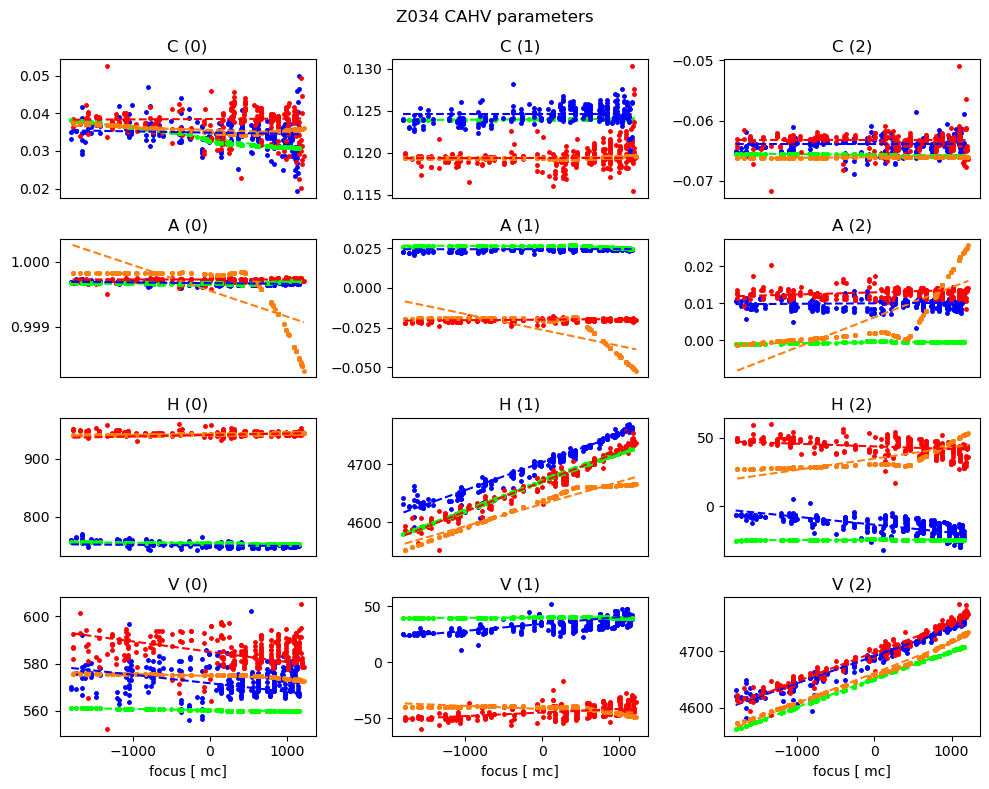

In [ ]:
s = ''
v_names = [ 'Cr0'+s, 'Cr1'+s, 'Cr2'+s, 'Ar0'+s, 'Ar1'+s, 'Ar2'+s, 'Hr0'+s, 'Hr1'+s, 'Hr2'+s, 'Vr0'+s, 'Vr1'+s, 'Vr2'+s, ]
v_sig   = [       1,       0,       0,       1,       1,       1,       1,       1,       1,       1,       1,       1, ]
# v_exc   = [       0,       0,       0,       0,       0,       0,       1,       0,       1,       0,       0,       0, ]


for l in [1]:

    plt.figure( figsize=[10,8])
    plt.suptitle( 'Z'+zooms[l]+ ' CAHV parameters' )

    for z in range(2):

        string = 'Z'+zcams[z]+zooms[l]+'\t '

        df_ = df[ (df['cam'] == 'Z'+zcams[z]+zooms[l])*( df['valid'] == True) ]

        ms = 5
        if l in [0,5]:
            ms = 7
        if l == 6:
            ms = 1
            # df_ = df[ (df['cam'] == 'Z'+zcams[z]+zooms[l])*( df['valid'] == True)*( df['fmc'] > 2000) ]


        x = df_[[ 'fmc' ]].values

        s = ''
        y =     df_[[ 'Cr0'+s, 'Cr1'+s, 'Cr2'+s, 'Ar0'+s, 'Ar1'+s, 'Ar2'+s, 'Hr0'+s, 'Hr1'+s, 'Hr2'+s, 'Vr0'+s, 'Vr1'+s, 'Vr2'+s,  ]].values

        s = '_est'
        y_est = df_[[ 'Cr0'+s, 'Cr1'+s, 'Cr2'+s, 'Ar0'+s, 'Ar1'+s, 'Ar2'+s, 'Hr0'+s, 'Hr1'+s, 'Hr2'+s, 'Vr0'+s, 'Vr1'+s, 'Vr2'+s,  ]].values


        x_min, x_max = [ np.min(x), np.max(x)]
        x_ = np.linspace( x_min, x_max, 2 )

        string += '{:}\t {:}\t '.format(x_min, x_max) 


        

        for v in range(len(v_names)):


            rho, _ = pearsonr( x[:,0], y[:,v])
            if abs(rho) > 0.3:
                a1, a0 = np.polyfit( x[:,0], y[:,v], 1)
            else: 
                a1, a0 = [ 0.0, np.median( y[:,v] )]

            if 0: 

                rho_est, _ = pearsonr( x[:,0], y_est[:,v])
                a1_est, a0_est = np.polyfit( x[:,0], y_est[:,v], 1)

                

            else:

                rho_est = 0.3

                ransac = RANSACRegressor()
                ransac.fit( x, y_est[:,v] )   

                a1_est, a0_est = [ ransac.estimator_.coef_[0], ransac.estimator_.intercept_,  ]


            if abs(rho_est) < 0.3  or ( v_sig[v]==0 ) :
                a1_est, a0_est = [ 0.0, np.median( y_est[:,v] )]

                 

            string += '{:.2f}\t {:.10f}\t {:.10f}\t '.format(rho_est, a1_est, a0_est) 
            
            y_est_ = a0_est + a1_est * x_


            # string += '{:.2f}\t {:}\t {:.10f}\t '.format(rho, a1, a0) 
            
            y_ = a0 + a1 * x_

            plt.subplot(4,3,1+v)
            plt.title( v_names[v][0]+' ('+ v_names[v][2]+')'  )

            if z==0:
                if v==1:
                    plt.plot( x, -y[:,v],     '.', color='lime', zorder=2, ms=ms )
                    plt.plot( x, -y_est[:,v], '.', color='blue', zorder=3, ms=ms )

                    plt.plot( x_,-y_    ,    '--', color='lime', zorder=2 ) 
                    plt.plot( x_,-y_est_,    '--', color='blue', zorder=4 ) 

                else:
                    plt.plot( x, y[:,v],     '.', color='lime', zorder=3, ms=ms )
                    plt.plot( x, y_est[:,v], '.', color='blue', ms=ms )

                    plt.plot( x_,y_    ,    '--', color='lime', zorder=2 ) 
                    plt.plot( x_,y_est_,    '--', color='blue', zorder=4 )
            else:
                plt.plot( x, y[:,v],         '.', color='C1', zorder=3, ms=ms )
                plt.plot( x, y_est[:,v],     '.', color='red',ms=ms )

                plt.plot( x_,y_    ,        '--', color='C1', zorder=3 ) 
                plt.plot( x_,y_est_,        '--', color='red', zorder=4 )

            if v>8:
                plt.xlabel('focus [ mc]')
            else:
                plt.xticks([])

        
        string += '{:.1f}\t {}\t {:.10f}\t '.format( 0.0, np.median(df_['k1']), np.median(df_['k2']) )
        print(string)

    plt.tight_layout()
    # plt.savefig( 'plots/CAHVr_vs_focus_'+zooms[l], dpi=400 )
    


In [ ]:
df.to_excel('plots/m41_site_cal_v226_v5.xlsx')


df.shape

(556, 151)

In [ ]:
# df = pd.read_excel( 'plots/m41_site_cal_v226_v5.xlsx')

In [ ]:
zcams =  ['L','R']

from sklearn.linear_model import LinearRegression, RANSACRegressor


from scipy.stats import pearsonr

ZL034	 -1800	 1158	 0.30	 -0.0000008860	 0.0351937921	 0.30	 0.0000000000	 -0.1245499639	 0.30	 0.0000000000	 -0.0638955755	 0.30	 -0.0000000137	 0.9996729384	 0.30	 -0.0000000926	 0.0242841068	 0.30	 0.0000004544	 0.0094820733	 0.30	 -0.0020557767	 751.2362452177	 0.30	 0.0526526280	 4700.6268037513	 0.30	 -0.0028743419	 -11.7167558190	 0.30	 -0.0020381321	 571.1940792899	 0.30	 0.0039402388	 31.6621925879	 0.30	 0.0483480115	 4690.8654075518	 0.0	 -0.469941	 0.6576490000	 
ZR034	 -1782	 1218	 0.30	 0.0000003110	 0.0389232933	 0.30	 0.0000000000	 0.1194306049	 0.30	 0.0000000000	 -0.0632976413	 0.30	 -0.0000000101	 0.9997194780	 0.30	 0.0000003724	 -0.0202152089	 0.30	 0.0000005217	 0.0124581008	 0.30	 -0.0008809923	 943.3769458311	 0.30	 0.0518289124	 4670.2216883502	 0.30	 -0.0061155033	 40.8735404606	 0.30	 0.0004853806	 583.0956834755	 0.30	 0.0034392491	 -44.7159516253	 0.30	 0.0524702777	 4697.2675947350	 0.0	 -0.481191	 0.7508650000	 


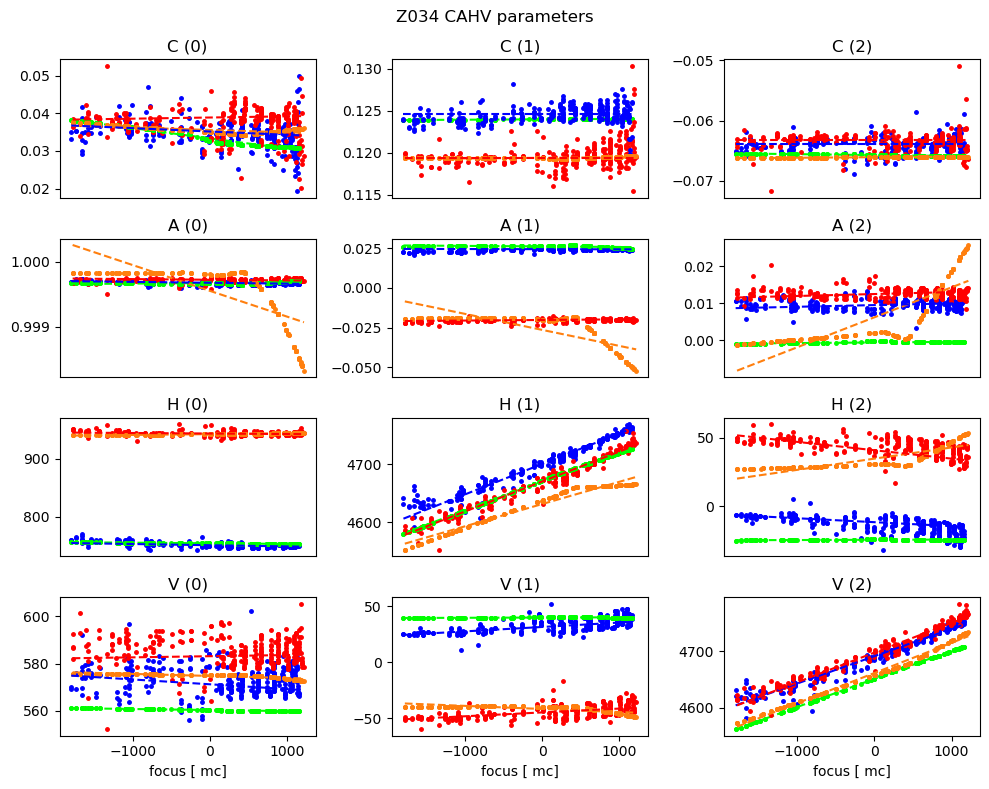

In [ ]:
s = ''
v_names = [ 'Cr0'+s, 'Cr1'+s, 'Cr2'+s, 'Ar0'+s, 'Ar1'+s, 'Ar2'+s, 'Hr0'+s, 'Hr1'+s, 'Hr2'+s, 'Vr0'+s, 'Vr1'+s, 'Vr2'+s, ]
v_sig   = [       1,       0,       0,       1,       1,       1,       1,       1,       1,       1,       1,       1, ]
# v_exc   = [       0,       0,       0,       0,       0,       0,       1,       0,       1,       0,       0,       0, ]


for l in [1]:

    plt.figure( figsize=[10,8])
    plt.suptitle( 'Z'+zooms[l]+ ' CAHV parameters' )

    for z in range(2):

        string = 'Z'+zcams[z]+zooms[l]+'\t '

        df_ = df[ (df['cam'] == 'Z'+zcams[z]+zooms[l])*( df['valid'] == True) ]

        ms = 5
        if l in [0,5]:
            ms = 7
        if l == 6:
            ms = 1
            # df_ = df[ (df['cam'] == 'Z'+zcams[z]+zooms[l])*( df['valid'] == True)*( df['fmc'] > 2000) ]


        x = df_[[ 'fmc' ]].values

        s = ''
        y =     df_[[ 'Cr0'+s, 'Cr1'+s, 'Cr2'+s, 'Ar0'+s, 'Ar1'+s, 'Ar2'+s, 'Hr0'+s, 'Hr1'+s, 'Hr2'+s, 'Vr0'+s, 'Vr1'+s, 'Vr2'+s,  ]].values

        s = '_est'
        y_est = df_[[ 'Cr0'+s, 'Cr1'+s, 'Cr2'+s, 'Ar0'+s, 'Ar1'+s, 'Ar2'+s, 'Hr0'+s, 'Hr1'+s, 'Hr2'+s, 'Vr0'+s, 'Vr1'+s, 'Vr2'+s,  ]].values


        x_min, x_max = [ np.min(x), np.max(x)]
        x_ = np.linspace( x_min, x_max, 2 )

        string += '{:}\t {:}\t '.format(x_min, x_max) 


        

        for v in range(len(v_names)):


            rho, _ = pearsonr( x[:,0], y[:,v])
            if abs(rho) > 0.3:
                a1, a0 = np.polyfit( x[:,0], y[:,v], 1)
            else: 
                a1, a0 = [ 0.0, np.median( y[:,v] )]

            if 0: 

                rho_est, _ = pearsonr( x[:,0], y_est[:,v])
                a1_est, a0_est = np.polyfit( x[:,0], y_est[:,v], 1)

                

            else:

                rho_est = 0.3

                ransac = RANSACRegressor()
                ransac.fit( x, y_est[:,v] )   

                a1_est, a0_est = [ ransac.estimator_.coef_[0], ransac.estimator_.intercept_,  ]


            if abs(rho_est) < 0.3  or ( v_sig[v]==0 ) :
                a1_est, a0_est = [ 0.0, np.median( y_est[:,v] )]

                 

            string += '{:.2f}\t {:.10f}\t {:.10f}\t '.format(rho_est, a1_est, a0_est) 
            
            y_est_ = a0_est + a1_est * x_


            # string += '{:.2f}\t {:}\t {:.10f}\t '.format(rho, a1, a0) 
            
            y_ = a0 + a1 * x_

            plt.subplot(4,3,1+v)
            plt.title( v_names[v][0]+' ('+ v_names[v][2]+')'  )

            if z==0:
                if v==1:
                    plt.plot( x, -y[:,v],     '.', color='lime', zorder=2, ms=ms )
                    plt.plot( x, -y_est[:,v], '.', color='blue', zorder=3, ms=ms )

                    plt.plot( x_,-y_    ,    '--', color='lime', zorder=2 ) 
                    plt.plot( x_,-y_est_,    '--', color='blue', zorder=4 ) 

                else:
                    plt.plot( x, y[:,v],     '.', color='lime', zorder=3, ms=ms )
                    plt.plot( x, y_est[:,v], '.', color='blue', ms=ms )

                    plt.plot( x_,y_    ,    '--', color='lime', zorder=2 ) 
                    plt.plot( x_,y_est_,    '--', color='blue', zorder=4 )
            else:
                plt.plot( x, y[:,v],         '.', color='C1', zorder=3, ms=ms )
                plt.plot( x, y_est[:,v],     '.', color='red',ms=ms )

                plt.plot( x_,y_    ,        '--', color='C1', zorder=3 ) 
                plt.plot( x_,y_est_,        '--', color='red', zorder=4 )

            if v>8:
                plt.xlabel('focus [ mc]')
            else:
                plt.xticks([])

        
        string += '{:.1f}\t {}\t {:.10f}\t '.format( 0.0, np.median(df_['k1']), np.median(df_['k2']) )
        print(string)

    plt.tight_layout()
    # plt.savefig( 'plots/CAHVr_vs_focus_'+zooms[l], dpi=400 )
    


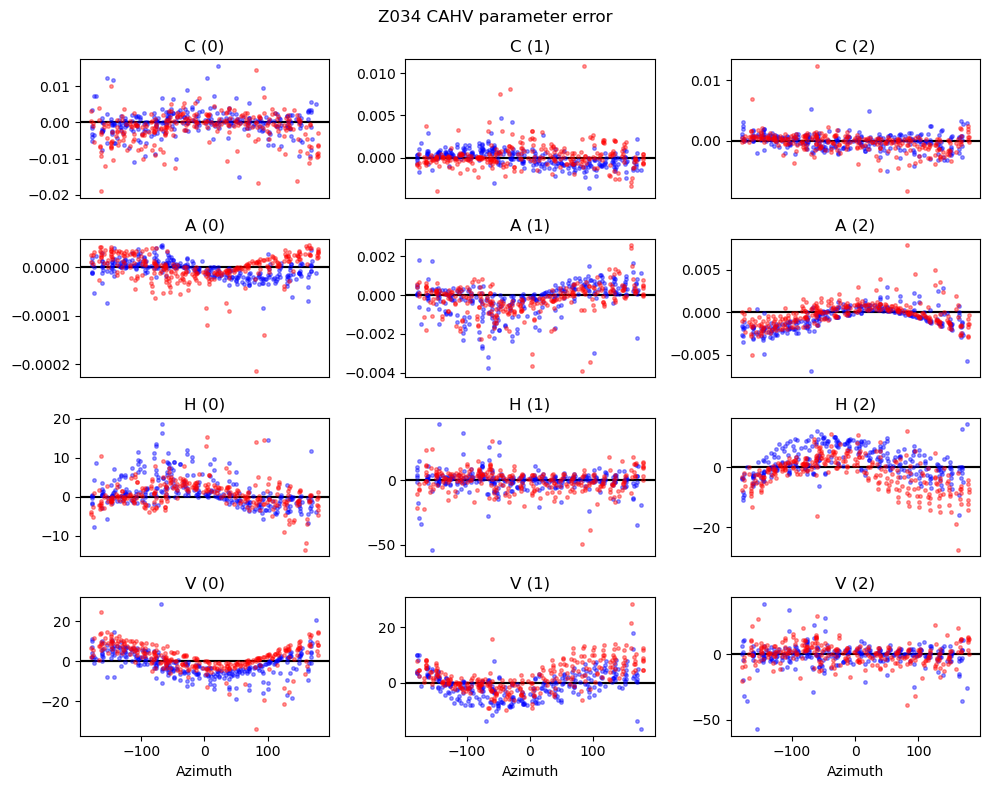

In [ ]:
s = ''
v_names = [ 'Cr0'+s, 'Cr1'+s, 'Cr2'+s, 'Ar0'+s, 'Ar1'+s, 'Ar2'+s, 'Hr0'+s, 'Hr1'+s, 'Hr2'+s, 'Vr0'+s, 'Vr1'+s, 'Vr2'+s, ]
v_sig   = [       1,       0,       0,       1,       1,       1,       1,       1,       1,       1,       1,       1, ]
# v_exc   = [       0,       0,       0,       0,       0,       0,       1,       0,       1,       0,       0,       0, ]


l = 6

for l in [1,]:

    plt.figure( figsize=[10,8])
    plt.suptitle( 'Z'+zooms[l]+ ' CAHV parameter error' )

    for z in range(2):

        string = 'Z'+zcams[z]+zooms[l]+'\t '


        




        df_ = df[ (df['cam'] == 'Z'+zcams[z]+zooms[l])*( df['valid'] == True) ]

        ms = 5
        if l == 6:
            ms = 1
            # df_ = df[ (df['cam'] == 'Z'+zcams[z]+zooms[l])*( df['valid'] == True)*( df['fmc'] > 2000) ]


        x = df_[[ 'fmc' ]].values

        s = ''
        y =     df_[[ 'Cr0'+s, 'Cr1'+s, 'Cr2'+s, 'Ar0'+s, 'Ar1'+s, 'Ar2'+s, 'Hr0'+s, 'Hr1'+s, 'Hr2'+s, 'Vr0'+s, 'Vr1'+s, 'Vr2'+s,  ]].values

        s = '_est'
        y_est = df_[[ 'Cr0'+s, 'Cr1'+s, 'Cr2'+s, 'Ar0'+s, 'Ar1'+s, 'Ar2'+s, 'Hr0'+s, 'Hr1'+s, 'Hr2'+s, 'Vr0'+s, 'Vr1'+s, 'Vr2'+s,  ]].values


        x_min, x_max = [ np.min(x), np.max(x)]
        # x_ = np.linspace( x_min, x_max, 2 )
        x_ = x

        # T = np.sin( np.deg2rad(df_[[ 'az' ]].values) )
        T = df_[[ 'az_center' ]].values 
        # T = df_[[ 'az_RSM' ]].values *57.3

        string += '{:}\t {:}\t '.format(x_min, x_max) 


        

        for v in range(len(v_names)):


            rho, _ = pearsonr( x[:,0], y[:,v])
            if abs(rho) > 0.3:
                a1, a0 = np.polyfit( x[:,0], y[:,v], 1)
            else: 
                a1, a0 = [ 0.0, np.median( y[:,v] )]

            if 0: 

                rho_est, _ = pearsonr( x[:,0], y_est[:,v])
                a1_est, a0_est = np.polyfit( x[:,0], y_est[:,v], 1)

                

            else:

                ransac = RANSACRegressor()
                ransac.fit( x, y_est[:,v] )   

                a1_est, a0_est = [ ransac.estimator_.coef_[0], ransac.estimator_.intercept_,  ]


            if abs(rho_est) < 0.3  or ( v_sig[v]==0 ) :
                a1_est, a0_est = [ 0.0, np.median( y_est[:,v] )]

                 

            string += '{:.2f}\t {}\t {:.10f}\t '.format(rho_est, a1_est, a0_est) 
            
            y_est_ = a0_est + a1_est * x_


            string += '{:.2f}\t {:}\t {:.10f}\t '.format(rho, a1, a0) 
            
            y_ = a0 + a1 * x_




            plt.subplot(4,3,1+v)
            plt.title( v_names[v][0]+' ('+ v_names[v][2]+')'  )

            if z==0:
                # plt.plot( T[:,0], y[:,v] - y_[:,0],     '.', color='C0', zorder=3, ms=ms )
                plt.plot( T[:,0], y_est[:,v] - y_est_[:,0], '.', color='blue', ms=ms, alpha=0.4 )

                # plt.plot( x_,y_    ,    '--', color='C0', zorder=4 ) 
                # plt.plot( x_,y_est_,    '--', color='blue', zorder=4 )
            else:
                # plt.plot( T[:,0], y[:,v] - y_[:,0],         '.', color='C1', zorder=3, ms=ms )
                plt.plot( T[:,0], y_est[:,v] - y_est_[:,0],     '.', color='red',ms=ms, alpha=0.4 )

                # plt.plot( x_,y_    ,    '--', color='C1', zorder=4 ) 
                # plt.plot( x_,y_est_,        '--', color='red', zorder=4 )

            if v>8:
                plt.xlabel('Azimuth')
            else:
                plt.xticks([])

            plt.axhline( 0, color='k', zorder=0)
            
            # plt.xlim([-180,180])
            

        # string += '{:.1f}\t {:.10f}\t {:.10f}\t '.format( 0.0, np.median(df_['k1']), np.median(df_['k2']) )
        # print(string)

    plt.tight_layout()
    # plt.savefig( 'plots/CAHVr_error_vs_az'+zooms[l], dpi=200 )
    


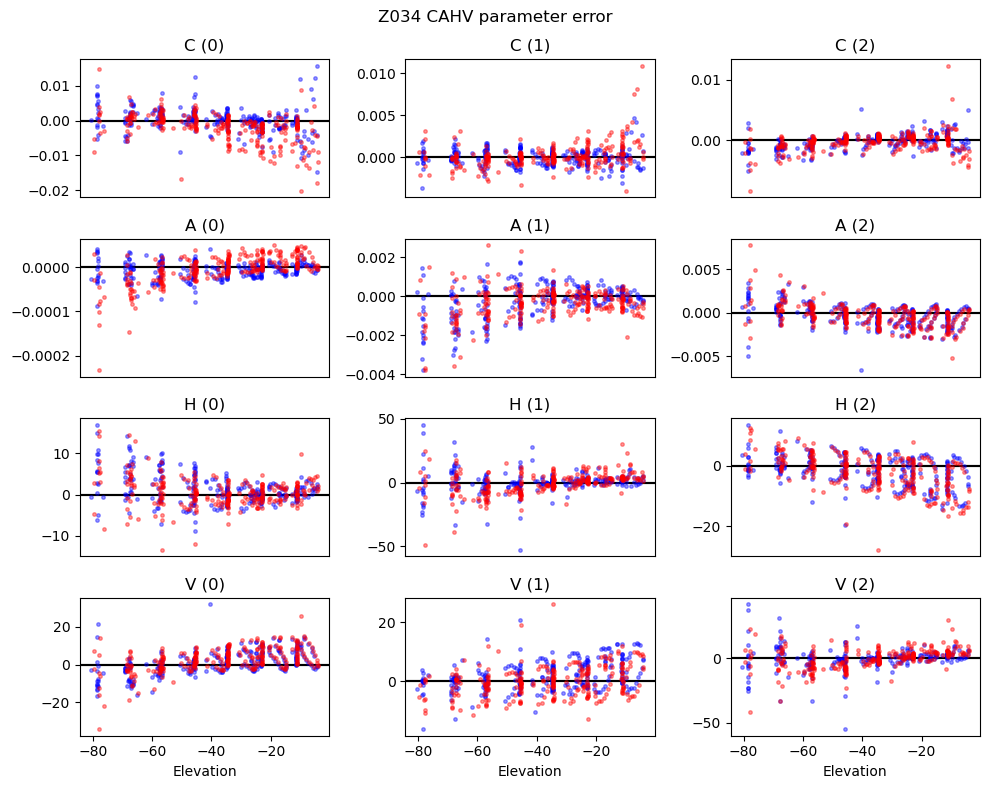

In [ ]:
s = ''
v_names = [ 'Cr0'+s, 'Cr1'+s, 'Cr2'+s, 'Ar0'+s, 'Ar1'+s, 'Ar2'+s, 'Hr0'+s, 'Hr1'+s, 'Hr2'+s, 'Vr0'+s, 'Vr1'+s, 'Vr2'+s, ]
v_sig   = [       1,       0,       0,       1,       1,       1,       1,       1,       1,       1,       1,       1, ]
# v_exc   = [       0,       0,       0,       0,       0,       0,       1,       0,       1,       0,       0,       0, ]


l = 6

for l in [1,]:

    plt.figure( figsize=[10,8])
    plt.suptitle( 'Z'+zooms[l]+ ' CAHV parameter error' )

    for z in range(2):

        string = 'Z'+zcams[z]+zooms[l]+'\t '


        




        df_ = df[ (df['cam'] == 'Z'+zcams[z]+zooms[l])*( df['valid'] == True) ]

        ms = 5
        if l == 6:
            ms = 1
            # df_ = df[ (df['cam'] == 'Z'+zcams[z]+zooms[l])*( df['valid'] == True)*( df['fmc'] > 2000) ]


        x = df_[[ 'fmc' ]].values

        s = ''
        y =     df_[[ 'Cr0'+s, 'Cr1'+s, 'Cr2'+s, 'Ar0'+s, 'Ar1'+s, 'Ar2'+s, 'Hr0'+s, 'Hr1'+s, 'Hr2'+s, 'Vr0'+s, 'Vr1'+s, 'Vr2'+s,  ]].values

        s = '_est'
        y_est = df_[[ 'Cr0'+s, 'Cr1'+s, 'Cr2'+s, 'Ar0'+s, 'Ar1'+s, 'Ar2'+s, 'Hr0'+s, 'Hr1'+s, 'Hr2'+s, 'Vr0'+s, 'Vr1'+s, 'Vr2'+s,  ]].values


        x_min, x_max = [ np.min(x), np.max(x)]
        # x_ = np.linspace( x_min, x_max, 2 )
        x_ = x

        # T = np.sin( np.deg2rad(df_[[ 'az' ]].values) )
        T = df_[[ 'el_center' ]].values 
        # T = df_[[ 'az_RSM' ]].values *57.3

        string += '{:}\t {:}\t '.format(x_min, x_max) 


        

        for v in range(len(v_names)):


            rho, _ = pearsonr( x[:,0], y[:,v])
            if abs(rho) > 0.3:
                a1, a0 = np.polyfit( x[:,0], y[:,v], 1)
            else: 
                a1, a0 = [ 0.0, np.median( y[:,v] )]

            if 0: 

                rho_est, _ = pearsonr( x[:,0], y_est[:,v])
                a1_est, a0_est = np.polyfit( x[:,0], y_est[:,v], 1)

                

            else:

                ransac = RANSACRegressor()
                ransac.fit( x, y_est[:,v] )   

                a1_est, a0_est = [ ransac.estimator_.coef_[0], ransac.estimator_.intercept_,  ]


            if abs(rho_est) < 0.3  or ( v_sig[v]==0 ) :
                a1_est, a0_est = [ 0.0, np.median( y_est[:,v] )]

                 

            string += '{:.2f}\t {}\t {:.10f}\t '.format(rho_est, a1_est, a0_est) 
            
            y_est_ = a0_est + a1_est * x_


            string += '{:.2f}\t {:}\t {:.10f}\t '.format(rho, a1, a0) 
            
            y_ = a0 + a1 * x_




            plt.subplot(4,3,1+v)
            plt.title( v_names[v][0]+' ('+ v_names[v][2]+')'  )

            if z==0:
                # plt.plot( T[:,0], y[:,v] - y_[:,0],     '.', color='C0', zorder=3, ms=ms )
                plt.plot( T[:,0], y_est[:,v] - y_est_[:,0], '.', color='blue', ms=ms, alpha=0.4 )

                # plt.plot( x_,y_    ,    '--', color='C0', zorder=4 ) 
                # plt.plot( x_,y_est_,    '--', color='blue', zorder=4 )
            else:
                # plt.plot( T[:,0], y[:,v] - y_[:,0],         '.', color='C1', zorder=3, ms=ms )
                plt.plot( T[:,0], y_est[:,v] - y_est_[:,0],     '.', color='red',ms=ms, alpha=0.4 )

                # plt.plot( x_,y_    ,    '--', color='C1', zorder=4 ) 
                # plt.plot( x_,y_est_,        '--', color='red', zorder=4 )

            if v>8:
                plt.xlabel('Elevation')
            else:
                plt.xticks([])

            plt.axhline( 0, color='k', zorder=0)
            
            # plt.xlim([-180,180])
            

        # string += '{:.1f}\t {:.10f}\t {:.10f}\t '.format( 0.0, np.median(df_['k1']), np.median(df_['k2']) )
        # print(string)

    plt.tight_layout()
    # plt.savefig( 'plots/CAHVr_error_vs_az'+zooms[l], dpi=200 )
    


In [ ]:
R_cam2ned  = R.from_matrix( [[0,-1,0],[1,0,0],[0,0,1]] ) 

X_est,Y_est,Z_est,omega_est,phi_est,kappa_est =  [ df.X_est[i], df.Y_est[i], df.Z_est[i], df.O_est[i], df.P_est[i], df.K_est[i] ]
X,Y,Z,omega,phi,kappa =  [ df.X[i], df.Y[i], df.Z[i], df.O[i], df.P[i], df.K[i] ]

f_est,cxp_est,cyp_est,b1_est,b2_est,k1_est,k2_est,k3_est,k4_est,p1_est,p2_est,w,h = [df['f_est'][i],df['cx_est'][i],df['cy_est'][i],df['b1_est'][i],df['b2_est'][i],df['k1_est'][i],df['k2_est'][i],df['k3_est'][i],df['k4_est'][i],df['p1_est'][i],df['p2_est'][i],df['w'][i],df['h'][i],]

cmod = df['cmod'][i]

opk_est = np.array([omega_est,phi_est,kappa_est ])
R_site2cam = find_R_from_opk( opk_est )


C_est = [ Y_est, X_est, -Z_est ]

cx_est = cxp_est+w/2
cy_est = cyp_est+h/2

theta_est = np.arctan2( -f_est-b1_est, b2_est)

K_est = np.array([
            [ f_est+b1_est, b2_est, cx_est ],
            [            0,  f_est, cy_est ],
            [            0,       0,     1 ], ]).astype('float64')

KnKR_est = R_cam2site.as_matrix().astype('float64')

HVA_est = np.matmul( K_est, R_cam2site.as_matrix() ).astype('float64')
H_est = HVA_est[0,:]
V_est = HVA_est[1,:]
A_est = HVA_est[2,:]
O_est = A_est
Ra_est = np.array([0,k1_est,k2_est])
E_est = np.array([0.0,0.0,0.0])

Hp_est = ( H_est - cx_est* A_est ) / f_est
Vp_est = ( V_est - cy_est* A_est ) / f_est

GEOMETRIC_CAMERA_MODEL = cmod_est
# GEOMETRIC_CAMERA_MODEL['REFERENCE_COORD_SYSTEM_NAME']  = 'SITE_FRAME'
# GEOMETRIC_CAMERA_MODEL['REFERENCE_COORD_SYSTEM_INDEX'] = '3'

GEOMETRIC_CAMERA_MODEL['MODEL_COMPONENT_1'] = list( C_est )
GEOMETRIC_CAMERA_MODEL['MODEL_COMPONENT_2'] = list( A_est )
GEOMETRIC_CAMERA_MODEL['MODEL_COMPONENT_3'] = list( H_est )
GEOMETRIC_CAMERA_MODEL['MODEL_COMPONENT_4'] = list( V_est )
GEOMETRIC_CAMERA_MODEL['MODEL_COMPONENT_5'] = list( O_est )
GEOMETRIC_CAMERA_MODEL['MODEL_COMPONENT_6'] = list( Ra_est )
GEOMETRIC_CAMERA_MODEL['MODEL_COMPONENT_7'] = list( E_est )

KnKR_est

AttributeError: 'DataFrame' object has no attribute 'O_est'

In [ ]:
# hs, vs, hc, vc, theta = hvt

C  = np.array( cmod['MODEL_COMPONENT_1'] ).astype('float64')
A  = np.array( cmod['MODEL_COMPONENT_2'] ).astype('float64')
H  = np.array( cmod['MODEL_COMPONENT_3'] ).astype('float64')
V  = np.array( cmod['MODEL_COMPONENT_4'] ).astype('float64')

hc = np.dot( H, A )
vc = np.dot( V, A )

hs = norm(np.cross( H, A ))
vs = norm(np.cross( V, A ))

Hp = (H - hc*A)/hs
Vp = (V - vc*A)/vs

Hp /= norm( Hp )
Vp /= norm( Vp )

theta = -np.arcsin(norm(np.cross(Vp,Hp)))
# theta = -np.arccos((np.dot(Vp,Hp)))

df['theta'][i] = theta

f =  vs
b1 = (-hs * np.sin(theta) - vs)
b2 =  hs * np.cos(theta)
# b1 = 0
# b2 = 0
cx =  hc - w/2
cy =  vc - h/2

HVA = np.array( [ H, V, A  ] )
K = np.array([
            [ f+b1, b2, hc ],
            [  0,  f, vc   ],
            [  0,  0,  1   ], ]) .astype('float64')
KnKR = np.matmul( inv(K), HVA ).astype('float64')

KnKR

C:\Users\cdt59\AppData\Local\Temp\ipykernel_305156\1136718584.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['theta'][i] = theta


array([[ 0.14872778, -0.98865615, -0.02058677],
       [ 0.48694635,  0.05510238,  0.87168327],
       [-0.860682  , -0.139668  ,  0.489627  ]])

In [ ]:
mat_opk_est

array([[-0.98888831, -0.05788766,  0.1369267 ],
       [ 0.14742046, -0.50056931,  0.85305192],
       [ 0.01916013,  0.86375887,  0.50354097]])

In [ ]:
np.matmul( mat_opk_, inv(KnKR))

array([[-0.09595227, -0.36648345,  0.92545662],
       [ 0.49175188,  0.79092511,  0.36418592],
       [-0.86544122,  0.49004348,  0.10432356]])

In [ ]:
mat_opk_

array([[-0.9892524 , -0.05458698,  0.1356464 ],
       [ 0.14482699, -0.49345678,  0.85762786],
       [ 0.02012032,  0.86805568,  0.49605898]])

In [ ]:
opk_est = np.array([omega_est,phi_est,kappa_est ])
R_site2cam_est = find_R_from_opk( opk_est )

R_site2cam = find_R_from_opk( opk )

R_site2cam_est.as_matrix(), R_site2cam.as_matrix()

(array([[-0.50056931, -0.05788766, -0.86375887],
        [ 0.14742046, -0.98888831, -0.01916013],
        [-0.85305192, -0.1369267 ,  0.50354097]]),
 array([[-0.49345678, -0.05458698, -0.86805568],
        [ 0.14482699, -0.9892524 , -0.02012032],
        [-0.85762786, -0.1356464 ,  0.49605898]]))

In [ ]:
R_ned2ms = np.array( [[0,1,0],[1,0,0],[0,0,-1]] ) 
R_   = KnKR
R_ms = np.matmul( R_,R_ned2ms )
Metashape.Utils.mat2opk( Metashape.Matrix( R_ms ) ), omega_est, phi_est, kappa_est

(Vector([119.32304739026428, 1.1796184592320522, -171.44490090679636]),
 -59.447422568500002,
 7.8700465271000004,
 176.64983637820001)

In [ ]:
R_rover2world  = np.array( [[0,1,0],[1,0,0],[0,0,-1]] )
R_cam2world  = np.array( [[0,-1,0],[1,0,0],[0,0,1]] )

R_rover2ms = np.matmul( R_rover2world, R_cam2world)

# rover frame to world frame
KnKR_world = np.matmul( inv(KnKR), (R_rover2ms))


Metashape.Utils.mat2opk( Metashape.Matrix(KnKR_world).inv())

Vector([122.13737929299478, -1.2364635053602682, 75.79001629392297])

In [ ]:
omega, phi, kappa, omega_est, phi_est, kappa_est

(-59.954560000000001,
 7.7960000000000003,
 -183.15837999999999,
 -59.447422568500002,
 7.8700465271000004,
 176.64983637820001)

In [ ]:
mat_opk     = np.array(Metashape.Utils.opk2mat( cam.reference.rotation )).reshape((3,3))
mat_opk_    = np.array(Metashape.Utils.opk2mat( [omega, phi, kappa] )).reshape((3,3))
mat_opk_est = np.array(Metashape.Utils.opk2mat( [omega_est, phi_est, kappa_est] )).reshape((3,3))


In [ ]:
opk = np.array([omega, phi, kappa] )
mat_opk_ms    = np.array(Metashape.Utils.opk2mat( opk )).reshape((3,3))
mat_opk_      = find_R_from_opk(  opk ).as_matrix()

mat_opk_ms, mat_opk_

(array([[-0.9892524 , -0.05458698,  0.1356464 ],
        [ 0.14482699, -0.49345678,  0.85762786],
        [ 0.02012032,  0.86805568,  0.49605898]]),
 array([[-0.49345678, -0.05458698, -0.86805568],
        [ 0.14482699, -0.9892524 , -0.02012032],
        [-0.85762786, -0.1356464 ,  0.49605898]]))

In [ ]:
R_site2ned  = np.array( [[0,1,0],[1,0,0],[0,0,-1]] ) 


T_chunk = doc.chunk.transform.matrix
R_chunk = doc.chunk.transform.rotation
T_cam   = cam.transform
T_est   = np.array( T_chunk*T_cam ).reshape((4,4))
T_est[:3,:3]   /= doc.chunk.transform.scale


KnKR_est_ = np.matmul( inv(T_est[:3,:3]), R_site2ned )

# is this the real
KnKR_est_, KnKR_est

(array([[ 0.14517865, -0.98916942, -0.02161053],
        [ 0.50033156,  0.05455436,  0.86411351],
        [-0.85357571, -0.13626326,  0.50283281]]),
 array([[ 0.14742046, -0.98888831, -0.01916013],
        [ 0.50056931,  0.05788766,  0.86375887],
        [-0.85305192, -0.1369267 ,  0.50354097]]))

In [ ]:



T_chunk = np.array( doc.chunk.transform.matrix).reshape((4,4))
R_chunk = np.array( doc.chunk.transform.rotation).reshape((3,3))

T_cam  = np.array( cam.transform).reshape((4,4))
R_cam  = T_cam[:3,:3]

T_world = np.matmul( T_chunk, T_cam )
T_world[:3,:3]   /= doc.chunk.transform.scale
t_world = T_est[3,:]
R_world = np.matmul( R_chunk, R_cam )

R_site2ned  = np.array( [[0,1,0],[1,0,0],[0,0,-1]] ) 
KnKR_est_ = np.matmul( inv(R_world), R_site2ned )

KnKR_est_

array([[ 0.14517865, -0.98916942, -0.02161053],
       [ 0.50033156,  0.05455436,  0.86411351],
       [-0.85357571, -0.13626326,  0.50283281]])

In [ ]:
Metashape.Utils.mat2opk( Metashape.Matrix(R_world))

Vector([120.50190804292795, -7.831674487369925, -176.8432391364762])

In [ ]:
(-59.954560000000001,
 7.7960000000000003,
 -183.15837999999999,
 -59.447422568500002,
 7.8700465271000004,
 176.64983637820001)

In [ ]:
cam_metmat = np.array(Metashape.Utils.opk2mat( cam.reference.rotation )).reshape((3,3))

np.matmul( inv(cam_metmat), KnKR_est_ )

array([[-0.12273737,  0.96394687,  0.23609738],
       [-0.99121006, -0.13090224,  0.01916281],
       [ 0.0493776 , -0.23167011,  0.97154043]])

In [ ]:
cam

<Camera 'ZL0_0023_0668981983_910RAD_N0030770ZCAM03003_0260LMA01'>

In [ ]:
np.matmul(KnKR_est_, inv(KnKR_est))

array([[  9.99993495e-01,  -3.48756692e-03,   9.20527845e-04],
       [  3.48634171e-03,   9.99993039e-01,   1.32924736e-03],
       [ -9.25157276e-04,  -1.32602944e-03,   9.99998693e-01]])

In [ ]:
np.matmul(KnKR_est_, inv(KnKR))

array([[ 0.99999928, -0.00302775,  0.0026958 ],
       [ 0.00306568,  0.999902  , -0.01419519],
       [-0.00264911,  0.01420585,  0.99988812]])

In [ ]:
help(cam)

Help on Camera in module Metashape.Metashape object:

class Camera(builtins.object)
 |  Camera instance
 |  
 |  >>> import Metashape
 |  >>> chunk = Metashape.app.document.addChunk()
 |  >>> chunk.addPhotos(["IMG_0001.jpg", "IMG_0002.jpg"])
 |  >>> camera = chunk.cameras[0]
 |  >>> camera.photo.meta["Exif/FocalLength"]
 |  '18'
 |  
 |  The following example describes how to create multispectal camera layout:
 |  
 |  >>> import Metashape
 |  >>> doc = Metashape.app.document
 |  >>> chunk = doc.chunk
 |  >>> rgb = ["RGB_0001.JPG", "RGB_0002.JPG", "RGB_0003.JPG"]
 |  >>> nir = ["NIR_0001.JPG", "NIR_0002.JPG", "NIR_0003.JPG"]
 |  >>> images = [[rgb[0], nir[0]], [rgb[1], nir[1]], [[rgb[2], nir[2]]
 |  >>> chunk.addPhotos(images, Metashape.MultiplaneLayout)
 |  
 |  Methods defined here:
 |  
 |  __eq__(self, value, /)
 |      Return self==value.
 |  
 |  __ge__(self, value, /)
 |      Return self>=value.
 |  
 |  __gt__(self, value, /)
 |      Return self>value.
 |  
 |  __hash__(self, /

In [ ]:
help(cam.reference)

Help on Reference object:

class Reference(builtins.object)
 |  Camera reference data.
 |  
 |  Static methods defined here:
 |  
 |  __new__(*args, **kwargs) from builtins.type
 |      Create and return a new object.  See help(type) for accurate signature.
 |  
 |  ----------------------------------------------------------------------
 |  Data descriptors defined here:
 |  
 |  accuracy
 |      Camera location accuracy.
 |      
 |      :type: :class:`Vector`
 |  
 |  enabled
 |      Location enabled flag.
 |      
 |      :type: bool
 |  
 |  location
 |      Camera coordinates.
 |      
 |      :type: :class:`Vector`
 |  
 |  location_accuracy
 |      Camera location accuracy.
 |      
 |      :type: :class:`Vector`
 |  
 |  location_enabled
 |      Location enabled flag.
 |      
 |      :type: bool
 |  
 |  rotation
 |      Camera rotation angles.
 |      
 |      :type: :class:`Vector`
 |  
 |  rotation_accuracy
 |      Camera rotation accuracy.
 |      
 |      :type: :class:`Ve

In [ ]:
T_est

array([[-0.97010099,  0.11299246, -0.2147947 ,  2.6695031 ],
       [ 0.24163692,  0.53246602, -0.81122841,  2.85294672],
       [ 0.02270819, -0.83887582, -0.54384897,  7.84385584],
       [ 0.        ,  0.        ,  0.        ,  4.0205838 ]])

In [ ]:
doc.chunk.transform.matrix

Matrix([[0.2165403694981626, 0.07690191210389988, -0.09517379867982001, 0.5014123502876506],
       [-0.12227110942882026, 0.1433650102772342, -0.16235127745120345, 0.9413044456060411],
       [0.004661742102295998, 0.18813361583129226, 0.16262133444784885, 1.9521353577163971],
       [0.0, 0.0, 0.0, 1.0]])

In [ ]:
doc.chunk.transform.rotation, 0.2165403694981626/doc.chunk.transform.scale

(Matrix([[0.8706187008625513, 0.30919058171419406, -0.38265423281030275],
        [-0.4916012413327188, 0.5764110372859184, -0.6527469154389788],
        [0.018742924759309783, 0.7564069673622857, 0.6538327022237854]]),
 0.8706187008625513)

In [ ]:
cmod

PVLGroup([
  ('CALIBRATION_SOURCE_ID', '1')
  ('MODEL_TYPE', 'CAHVOR')
  ('MODEL_COMPONENT_ID', ['C', 'A', 'H', 'V', 'O', 'R'])
  ('MODEL_COMPONENT_NAME',
   ['CENTER', 'AXIS', 'HORIZONTAL', 'VERTICAL', 'OPTICAL', 'RADIAL'])
  ('MODEL_COMPONENT_UNIT', ['METER', 'N/A', 'PIXEL', 'PIXEL', 'N/A', 'N/A'])
  ('MODEL_COMPONENT_1', [0.70498, 0.663231, -1.95006])
  ('MODEL_COMPONENT_2', [-0.818059, -0.21899, 0.531825])
  ('MODEL_COMPONENT_3', [210.234, -3834.8, 382.43])
  ('MODEL_COMPONENT_4', [1485.47, 298.453, 3490.04])
  ('MODEL_COMPONENT_5', [-0.817939, -0.218804, 0.532088])
  ('MODEL_COMPONENT_6', [-3.17512e-05, -0.450438, 0.320654])
  ('MODEL_TRANSFORM_VECTOR', [0.804898, 0.559427, -1.91903])
  ('MODEL_TRANSFORM_QUATERNION', [0.109402, -0.274714, -0.0302833, -0.954802])
  ('REFERENCE_COORD_SYSTEM_NAME', 'ROVER_NAV_FRAME')
  ('REFERENCE_COORD_SYSTEM_INDEX', [3, 770, 82])
  ('INTERPOLATION_METHOD', 'ZOOM')
  ('INTERPOLATION_VALUE', 504.0)
])

In [ ]:
KnKR, KnKR_est

(array([[ 0.06614944, -1.01715865,  0.09496442],
        [ 0.3896452 ,  0.07793008,  0.93141762],
        [-0.818059  , -0.21899   ,  0.531825  ]]),
 array([[ 0.24424222, -0.96950203, -0.02028658],
        [ 0.5326953 ,  0.11665979,  0.83822802],
        [-0.81029714, -0.21553723,  0.54494243]]))

In [ ]:


T =  np.array( df['T_est'][i])

R = np.array( [ T[0:3], T[4:7], T[8:11] ])
t = np.array( [ T[3], T[7], T[11]])


# T_chunk = doc.chunk.transform.matrix
# T_cam   = cam.transform

T = np.array( T_chunk*T_cam, dtype='float64' ).reshape((4,4))
T[:3,:3] /= doc.chunk.transform.scale

T

array([[-0.98916942,  0.05455436, -0.13626326,  0.67327324],
       [ 0.14517865,  0.50033156, -0.85357571,  0.7216133 ],
       [ 0.02161053, -0.86411351, -0.50283281,  1.95434829],
       [ 0.        ,  0.        ,  0.        ,  1.        ]])

In [ ]:
doc.chunk.transform.matrix

cam.transform

Matrix([[-0.9629514576720862, -0.14348727378077306, 0.2283328544694487, 0.8592235217724865],
       [-0.1791105940351639, -0.2926760155986366, -0.9392870407908738, 0.4181423308517238],
       [0.20160328685707396, -0.9453846583038398, 0.2561327050030052, -0.6180503203298489],
       [0.0, 0.0, 0.0, 1.0]])

In [ ]:
df.Z_est, df.Z

(0    1.954065
 Name: Z_est, dtype: float64,
 0    1.95277
 Name: Z, dtype: float64)

In [ ]:
R_site2cam.as_matrix()

array([[-0.5326953 , -0.11665979, -0.83822802],
       [ 0.24424222, -0.96950203, -0.02028658],
       [-0.81029714, -0.21553723,  0.54494243]])

In [ ]:
df.to_excel('plots/m41_site_cal_v224_v4_.xlsx')


df.shape

(0, 28)

In [ ]:
# s = ''
# v_names = [ 'Cr0'+s, 'Cr1'+s, 'Cr2'+s, 'Ar0'+s, 'Ar1'+s, 'Ar2'+s, 'Hr0'+s, 'Hr1'+s, 'Hr2'+s, 'Vr0'+s, 'Vr1'+s, 'Vr2'+s, ]
# v_sig   = [       1,       0,       0,       1,       1,       1,       1,       1,       1,       1,       1,       1, ]
# # v_exc   = [       0,       0,       0,       0,       0,       0,       1,       0,       1,       0,       0,       0, ]

# zcams =  ['L','R']

# from sklearn.linear_model import LinearRegression, RANSACRegressor


# from scipy.stats import pearsonr

# df['sol']   = [ int(df['name'][i][4:8]) for i in range(df.shape[0]) ]
# sol_min = 10
# df['valid'] = False
# df['valid'][ (np.isnan( df['Ar0_est'] ) == False)*( df['sol'] >= sol_min ) ] = True
# df['valid'][ ((df['cam'] == 'ZL110') + (df['cam'] == 'ZR110'))*( (df['f_est']<14580) + (df['f_est']> 14920)) ] = False


# for l in range(1,2):

#     plt.figure( figsize=[10,8])
#     plt.suptitle( 'Z'+zooms[l]+ ' CAHV parameters' )

#     for z in range(2):

#         string = 'Z'+zcams[z]+zooms[l]+'\t '

#         df_ = df[ (df['cam'] == 'Z'+zcams[z]+zooms[l])*( df['valid'] == True) ]

#         ms = 6
#         if l in [0,5]:
#             ms = 7
#         if l == 6:
#             ms = 2
#             # df_ = df[ (df['cam'] == 'Z'+zcams[z]+zooms[l])*( df['valid'] == True)*( df['fmc'] > 2000) ]


#         x = df_[[ 'fmc' ]].values

#         s = ''
#         y =     df_[[ 'Cr0'+s, 'Cr1'+s, 'Cr2'+s, 'Ar0'+s, 'Ar1'+s, 'Ar2'+s, 'Hr0'+s, 'Hr1'+s, 'Hr2'+s, 'Vr0'+s, 'Vr1'+s, 'Vr2'+s,  ]].values

#         s = '_est'
#         y_est = df_[[ 'Cr0'+s, 'Cr1'+s, 'Cr2'+s, 'Ar0'+s, 'Ar1'+s, 'Ar2'+s, 'Hr0'+s, 'Hr1'+s, 'Hr2'+s, 'Vr0'+s, 'Vr1'+s, 'Vr2'+s,  ]].values


#         x_min, x_max = [ np.min(x), np.max(x)]
#         x_ = np.linspace( x_min, x_max, 2 )

#         string += '{:}\t {:}\t '.format(x_min, x_max) 


        

#         for v in range(len(v_names)):


#             rho_est, _ = pearsonr( x[:,0], y_est[:,v])
#             a1_est, a0_est = np.polyfit( x[:,0], y_est[:,v], 1)

#             ransac = RANSACRegressor()
#             ransac.fit( x, y_est[:,v] )   

#             a1_est, a0_est = [ ransac.estimator_.coef_[0], ransac.estimator_.intercept_,  ]


#             if abs(rho_est) < 0.3  or ( v_sig[v]==0 ) :
#                 a1_est, a0_est = [ 0.0, np.median( y_est[:,v] )]

                 

#             string += '{:.2f}\t {}\t {:.10f}\t '.format(rho_est, a1_est, a0_est) 
            
#             y_est_ = a0_est + a1_est * x_
            

#             rho, _ = pearsonr( x[:,0], y[:,v])
#             if abs(rho) > 0.3:
#                 a1, a0 = np.polyfit( x[:,0], y[:,v], 1)
#             else: 
#                 a1, a0 = [ 0.0, np.median( y[:,v] )]

#             # string += '{:.2f}\t {:}\t {:.10f}\t '.format(rho, a1, a0) 
            
#             y_ = a0 + a1 * x_

#             plt.subplot(4,3,1+v)
#             plt.title( v_names[v][0]+' ('+ v_names[v][2]+')'  )

#             if z==0:
#                 if v==1:
#                     plt.plot( x, -y[:,v],     '.', color='lime', zorder=2, ms=ms, alpha=0.4 )
#                     plt.plot( x, -y_est[:,v], '.', color='blue', zorder=3, ms=ms, alpha=0.4 )

#                     plt.plot( x_,-y_    ,    '--', color='lime', zorder=2 ) 
#                     plt.plot( x_,-y_est_,    '--', color='blue', zorder=4 ) 

#                 else:
#                     plt.plot( x, y[:,v],     '.', color='lime', zorder=3, ms=ms, alpha=0.4 )
#                     plt.plot( x, y_est[:,v], '.', color='blue', ms=ms, alpha=0.4 )

#                     plt.plot( x_,y_    ,    '--', color='lime', zorder=2 ) 
#                     plt.plot( x_,y_est_,    '--', color='blue', zorder=4 )
#             else:
#                 plt.plot( x, y[:,v],         '.', color='C1', zorder=3, ms=ms, alpha=0.4 )
#                 plt.plot( x, y_est[:,v],     '.', color='red',ms=ms, alpha=0.4 )

#                 plt.plot( x_,y_    ,        '--', color='C1', zorder=3 ) 
#                 plt.plot( x_,y_est_,        '--', color='red', zorder=4 )

#             if v>8:
#                 plt.xlabel('focus [ mc]')
#             else:
#                 plt.xticks([])

        
#         string += '{:.1f}\t {:.10f}\t {:.10f}\t '.format( 0.0, np.median(df_['k1']), np.median(df_['k2']) )
#         print(string)

#     plt.tight_layout()


In [ ]:
# s = ''
# v_names = [ 'Cr0'+s, 'Cr1'+s, 'Cr2'+s, 'Ar0'+s, 'Ar1'+s, 'Ar2'+s, 'Hr0'+s, 'Hr1'+s, 'Hr2'+s, 'Vr0'+s, 'Vr1'+s, 'Vr2'+s, ]
# v_sig   = [       1,       0,       0,       1,       1,       1,       1,       1,       1,       1,       1,       1, ]
# # v_exc   = [       0,       0,       0,       0,       0,       0,       1,       0,       1,       0,       0,       0, ]


# l = 6

# for l in range(6,7):

#     plt.figure( figsize=[10,8])
#     plt.suptitle( 'Z'+zooms[l]+ ' CAHV parameter error' )

#     for z in range(2):

#         string = 'Z'+zcams[z]+zooms[l]+'\t '


        




#         df_ = df[ (df['cam'] == 'Z'+zcams[z]+zooms[l])*( df['valid'] == True) ]

#         ms = 5
#         if l == 6:
#             ms = 1
#             # df_ = df[ (df['cam'] == 'Z'+zcams[z]+zooms[l])*( df['valid'] == True)*( df['fmc'] > 2000) ]


#         x = df_[[ 'fmc' ]].values

#         s = ''
#         y =     df_[[ 'Cr0'+s, 'Cr1'+s, 'Cr2'+s, 'Ar0'+s, 'Ar1'+s, 'Ar2'+s, 'Hr0'+s, 'Hr1'+s, 'Hr2'+s, 'Vr0'+s, 'Vr1'+s, 'Vr2'+s,  ]].values

#         s = '_est'
#         y_est = df_[[ 'Cr0'+s, 'Cr1'+s, 'Cr2'+s, 'Ar0'+s, 'Ar1'+s, 'Ar2'+s, 'Hr0'+s, 'Hr1'+s, 'Hr2'+s, 'Vr0'+s, 'Vr1'+s, 'Vr2'+s,  ]].values


#         x_min, x_max = [ np.min(x), np.max(x)]
#         # x_ = np.linspace( x_min, x_max, 2 )
#         x_ = x

#         # T = np.sin( np.deg2rad(df_[[ 'az' ]].values) )
#         T = df_[[ 'az' ]].values 

#         string += '{:}\t {:}\t '.format(x_min, x_max) 


        

#         for v in range(len(v_names)):


#             rho_est, _ = pearsonr( x[:,0], y_est[:,v])
#             a1_est, a0_est = np.polyfit( x[:,0], y_est[:,v], 1)

#             # ransac = RANSACRegressor()
#             # ransac.fit( x, y_est[:,v] )   

#             # a1_est, a0_est = [ ransac.estimator_.coef_[0], ransac.estimator_.intercept_,  ]


#             if abs(rho_est) < 0.3  or ( v_sig[v]==0 ) :
#                 a1_est, a0_est = [ 0.0, np.median( y_est[:,v] )]

                 

#             string += '{:.2f}\t {}\t {:.10f}\t '.format(rho_est, a1_est, a0_est) 
            
#             y_est_ = a0_est + a1_est * x_
            

#             rho, _ = pearsonr( x[:,0], y[:,v])
#             if abs(rho) > 0.3:
#                 a1, a0 = np.polyfit( x[:,0], y[:,v], 1)
#             else: 
#                 a1, a0 = [ 0.0, np.median( y[:,v] )]

#             # string += '{:.2f}\t {:}\t {:.10f}\t '.format(rho, a1, a0) 
            
#             y_ = a0 + a1 * x_

#             plt.subplot(4,3,1+v)
#             plt.title( v_names[v][0]+' ('+ v_names[v][2]+')'  )

#             if z==0:
#                 # plt.plot( T[:,0], y[:,v] - y_[:,0],     '.', color='C0', zorder=3, ms=ms )
#                 plt.plot( T[:,0], y_est[:,v] - y_est_[:,0], '.', color='blue', ms=ms, alpha=0.4 )

#                 # plt.plot( x_,y_    ,    '--', color='C0', zorder=4 ) 
#                 # plt.plot( x_,y_est_,    '--', color='blue', zorder=4 )
#             else:
#                 # plt.plot( T[:,0], y[:,v] - y_[:,0],         '.', color='C1', zorder=3, ms=ms )
#                 plt.plot( T[:,0], y_est[:,v] - y_est_[:,0],     '.', color='red',ms=ms, alpha=0.4 )

#                 # plt.plot( x_,y_    ,    '--', color='C1', zorder=4 ) 
#                 # plt.plot( x_,y_est_,        '--', color='red', zorder=4 )

#             if v>8:
#                 plt.xlabel('Azimuth')
#             else:
#                 plt.xticks([])

#             plt.axhline( 0, color='k', zorder=0)
#             plt.xlim([-180,180])
            

#         # string += '{:.1f}\t {:.10f}\t {:.10f}\t '.format( 0.0, np.median(df_['k1']), np.median(df_['k2']) )
#         # print(string)

#     plt.tight_layout()
#     # plt.savefig( 'plots/CAHV_error_vs_az'+zooms[l], dpi=200 )
    


In [ ]:
# %run MPPP.py

# xy_pixels_cent = np.array([[[ h/2,   w/2,   1.]]])
# ray, ray_no_distort, u, u_no_distort, hvt = cahvor_pixels_2_ray( cmod, xy_pixels_cent )

# az = np.deg2rad( np.arctan2(  ray[0,0,:][1], ray[0,0,:][0] ) )
# el = np.deg2rad( np.arcsin ( -ray[0,0,:][2] ) )

# # xy_pixels_cent = np.array([[[ h,   w/2,   0]],[[ 0,   w/2,   0.]]])

# # ray, ray_no_distort, u, u_no_distort, hvt = cahvor_pixels_2_ray( cmod, xy_pixels_cent )
# # df['rl'][i] = angle( ray_cent[0,0,:] - ray_cent[0,1,:], np.array([0.0,  1.0, 0.0]))*d 
# # if df['rl'][i] > 90: df['rl'][i] -= 180


In [ ]:

# df_f =  pd.read_csv('fl_focus.csv')


# for i in range(df.shape[0])[:]:

#     cam = df.cam[i]

#     df_f_filtered = df_f[ df_f.cam == df.cam[i] ]

#     a0, a1 = [ df_f_filtered.a0.values[0], df_f_filtered.a1.values[0] ]

#     fmc = df.fmc[i]

#     df['a0_'][i] = a0
#     df['a1_'][i] = a1
#     df['f_'][i] = a0 + a1 * np.float(fmc)

In [ ]:
# # df['bl'] = np.nan
# # df['bl_est'] = np.nan
# # df['e_bl'] = np.nan

# df['blr'] = np.nan
# df['blr_est'] = np.nan
# df['e_blr'] = np.nan

# # df['ti'] = np.nan
# # df['ti_est'] = np.nan
# # df['e_ti'] = np.nan

# df['tir'] = np.nan
# df['tir_est'] = np.nan
# df['e_tir'] = np.nan



# for i in range(df.shape[0]):
    
#     if df.name[i][1] == 'L':
#         df_name = df.loc[df['name'] == 'ZR'+df.name[i][2:]]
#     if df.name[i][1] == 'R':
#         df_name = df.loc[df['name'] == 'ZL'+df.name[i][2:]]

#     if df_name.shape[0] == 1:
#         df['blr'][i]     = np.abs(df['Xr'][i] ) + np.abs(df_name['Xr']).values[0]
#         df['blr_est'][i] = np.abs(df['Xr_est'][i] ) + np.abs(df_name['Xr_est']).values[0]
#         df['e_blr'][i]   = df['blr_est'][i] - df['blr'][i]

#         try:
#           df['tir'][i]     = angle( df['rayc'][i],     df_name['rayc'].values[0]    )*d
#           df['tir_est'][i] = angle( df['rayc_est'][i], df_name['rayc_est'].values[0] )*d
#           df['e_tir'][i]   = df['tir_est'][i] - df['tir'][i]
#         except: pass

In [ ]:
df.to_excel('plots/m41_site_cal_v224_v1_.xlsx')


df.shape

(3741, 181)

In [ ]:
ls     = [ 0000, 2448,3834,5196,6720,8652,9600] 
zooms  = ['026','034','048','063','079','100','110']
ks     = [ 0]
zcams =  ['L','R']
fmc_ref = np.array( [ [ -2364, 108,1326,2214,2706,2718,2484 ],
                      [ -2106, 108,1278,2154,2646,2640,2406 ],] )

for i in range(df.shape[0]):

    cams = df['cam'][i]
    fl_index = zooms.index( cams[2:] )
    if cams[:2] == 'ZL':
        df['fmc_ref'][i] = fmc_ref[0,fl_index]
    if cams[:2] == 'ZR':
        df['fmc_ref'][i] = fmc_ref[1,fl_index]


C:\Users\cdt59\AppData\Local\Temp\ipykernel_153088\3140649295.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['fmc_ref'][i] = fmc_ref[0,fl_index]
C:\Users\cdt59\AppData\Local\Temp\ipykernel_153088\3140649295.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['fmc_ref'][i] = fmc_ref[1,fl_index]


In [ ]:

def CAHV_Rp_model( x, q_RRp_i, q_RRp_j, q_RRp_k, q_RRp_w,   t_RRp_i, t_RRp_j, t_RRp_k,   
                    q_CM_i0,q_CM_j0, q_CM_k0,q_CM_w0,   q_CM_i1, q_CM_j1, q_CM_k1, q_CM_w1,  C_M_i0, C_M_j0, C_M_k0,  C_M_i1, C_M_j1, C_M_k1,   fl0, fl1 ):

    # number of data points
    N = x.shape[0]

    # transform from Mast-frame to Rover-frame
    # q_MRs = x[:,0:4]
    # R_MRs = R.from_quat( q_MRs ).as_matrix()
    # t_MRs = x[:,4:7]

    q_RMs = x[:,0:4]
    R_RMs = R.from_quat( q_RMs ).as_matrix()
    t_RMs = x[:,4:7]

    # focus values
    fs  = x[:,7]
    fnorm = 1.0
    fs_ = fs / fnorm

    # transform from Rover-frame to Rover-frame prime
    q_RRp_norm = np.sqrt( q_RRp_i**2  + q_RRp_j**2  + q_RRp_k**2  + q_RRp_w**2 )
    q_RRp_i /= q_RRp_norm
    q_RRp_j /= q_RRp_norm
    q_RRp_k /= q_RRp_norm
    q_RRp_w /= q_RRp_norm
    
    q_RRp = np.array( [ q_RRp_i, q_RRp_j, q_RRp_k, q_RRp_w ] ) 
    t_RRp = np.array( [ t_RRp_i, t_RRp_j, t_RRp_k ] ) 

    # q_RRp = np.array( [ 0, 0, 0, 1 ] ) 
    # t_RRp = np.array( [ 0, 0, 0 ] ) 


    R_RRp = R.from_quat( q_RRp ).as_matrix()
    


    # focus dependent transform from Rover-frame to Rover-frame prime
    q_CM_norm = np.sqrt( q_CM_i0**2  + q_CM_j0**2  + q_CM_k0**2  + q_CM_w0**2 )
    q_CM_i0 /= q_CM_norm
    q_CM_k0 /= q_CM_norm
    q_CM_k0 /= q_CM_norm
    q_CM_w0 /= q_CM_norm
    q_CM_i1 /= q_CM_norm
    q_CM_k1 /= q_CM_norm
    q_CM_k1 /= q_CM_norm
    q_CM_w1 /= q_CM_norm
    q_CM_0 = np.array( [ q_CM_i0, q_CM_j0, q_CM_k0, q_CM_w0 ] ) 
    q_CM_1 = np.array( [ q_CM_i1, q_CM_j1, q_CM_k1, q_CM_w1 ] ) 
    q_CMs  = np.tile(q_CM_0, (N, 1)) + ( np.tile(q_CM_1, (N, 1)) * np.tile(fs_, (4, 1)).T ) * fnorm
    R_CMs  = R.from_quat( q_CMs ).as_matrix()

    C_M_0 = np.array( [ C_M_i0, C_M_j0, C_M_k0 ] ) 
    C_M_1 = np.array( [ C_M_i1, C_M_j1, C_M_k1 ] ) 
    C_Ms = np.tile( C_M_0, (N, 1)) + ( np.tile( C_M_1, (N, 1)) * np.tile(fs_, (3, 1)).T ) * fnorm

    # focus dependent focal length
    fls = fl0 * np.ones(N) + ( fl1 * fs_ ) * fnorm

    CAHV_Rps = []
    for i in range(N):

        fl = fls[i]
        Kc = np.array( [ [ fl+b1_est, b2_est, cx_est + 824 ], [ 0, fl, cy_est + 600 ], [ 0, 0, 1 ] ])

        R_CM = R_CMs[i]
        C_M  = C_Ms [i]

        R_RM = R_RMs[i]
        t_RM = t_RMs[i]

        R_RpR = R_RRp.T
        t_RpR = - (R_RRp.T) @ t_RRp

        R_MR =  R_RM.T
        t_MR = - (R_RM.T) @ t_RM

        # HVA_Rp =  Kc @ ( R_RRp.T @ ( R_MR.T @ R_CM.T ) )
        # C_Rp   =  R_RRp.T @ ( (R_MR.T  @ ( C_M - t_MR )) - t_RRp )

        # C_Rp   =  R_RRp.T @ ( (R_MR.T  @ ( C_M - t_MR )) - t_RRp )
        # HVA_Rp =  Kc @ (R_CM @ (R_MR @ R_RRp))

        # C_Rp   =  R_RRp @ ( (R_MR.T  @ ( C_M - t_MR )) - -R_RRp.T @ t_RRp )
        # HVA_Rp =  Kc @ (R_CM @ (R_MR @ R_RRp ))


        C_Rp   =  R_RRp @ ( (R_MR.T  @ ( C_M - t_MR )) - -R_RRp.T @ t_RRp )
        HVA_Rp =  Kc @ (R_CM @ (R_MR @ R_RRp.T))

        # C_Rp   =  R_RpR.T @  (R_RM @ C_M + t_RM ) + t_RpR 
        # HVA_Rp =  Kc @ (R_CM @ (R_MR @ R_RRp.T))


        CAHV_Rp = np.array( list( C_Rp) + list( HVA_Rp[2,:] ) + list( HVA_Rp[0,:] ) + list( HVA_Rp[1,:] )  )

        CAHV_Rps.append( CAHV_Rp )
        
        
    CAHV_Rps = np.array(CAHV_Rps) 

    return CAHV_Rps.flatten()

In [ ]:

def CAHV_Rp_model( x, q_RRp_i, q_RRp_j, q_RRp_k, q_RRp_w,   t_RRp_i, t_RRp_j, t_RRp_k,   q_CM_i0,q_CM_j0, q_CM_k0,q_CM_w0,   q_CM_i1, q_CM_j1, q_CM_k1, q_CM_w1,  C_M_i0, C_M_j0, C_M_k0,  C_M_i1, C_M_j1, C_M_k1,   fl0, fl1 ):

    # number of data points
    N = x.shape[0]

    # transform from Mast-frame to Rover-frame
    # q_MRs = x[:,0:4]
    # R_MRs = R.from_quat( q_MRs ).as_matrix()
    # t_MRs = x[:,4:7]

    q_RMs = x[:,0:4]
    R_RMs = R.from_quat( q_RMs ).as_matrix()
    t_RMs = x[:,4:7]

    # focus values
    fs  = x[:,7]
    fnorm = 1.0
    fs_ = fs / fnorm

    # transform from Rover-frame to Rover-frame prime
    q_RRp_norm = np.sqrt( q_RRp_i**2  + q_RRp_j**2  + q_RRp_k**2  + q_RRp_w**2 )
    q_RRp_i /= q_RRp_norm
    q_RRp_j /= q_RRp_norm
    q_RRp_k /= q_RRp_norm
    q_RRp_w /= q_RRp_norm
    
    q_RRp = np.array( [ q_RRp_i, q_RRp_j, q_RRp_k, q_RRp_w ] ) 
    t_RRp = np.array( [ t_RRp_i, t_RRp_j, t_RRp_k ] ) 

    # q_RRp = np.array( [ 0, 0, 0, 1 ] ) 
    # t_RRp = np.array( [ 0, 0, 0 ] ) 


    R_RRp = R.from_quat( q_RRp ).as_matrix()
    


    # focus dependent transform from Rover-frame to Rover-frame prime
    q_CM_norm = np.sqrt( q_CM_i0**2  + q_CM_j0**2  + q_CM_k0**2  + q_CM_w0**2 )
    q_CM_i0 /= q_CM_norm
    q_CM_k0 /= q_CM_norm
    q_CM_k0 /= q_CM_norm
    q_CM_w0 /= q_CM_norm
    q_CM_i1 /= q_CM_norm
    q_CM_k1 /= q_CM_norm
    q_CM_k1 /= q_CM_norm
    q_CM_w1 /= q_CM_norm
    q_CM_0 = np.array( [ q_CM_i0, q_CM_j0, q_CM_k0, q_CM_w0 ] ) 
    q_CM_1 = np.array( [ q_CM_i1, q_CM_j1, q_CM_k1, q_CM_w1 ] ) 
    q_CMs  = np.tile(q_CM_0, (N, 1)) + ( np.tile(q_CM_1, (N, 1)) * np.tile(fs_, (4, 1)).T ) * fnorm
    R_CMs  = R.from_quat( q_CMs ).as_matrix()

    C_M_0 = np.array( [ C_M_i0, C_M_j0, C_M_k0 ] ) 
    C_M_1 = np.array( [ C_M_i1, C_M_j1, C_M_k1 ] ) 
    C_Ms = np.tile( C_M_0, (N, 1)) + ( np.tile( C_M_1, (N, 1)) * np.tile(fs_, (3, 1)).T ) * fnorm

    # focus dependent focal length
    fls = fl0 * np.ones(N) + ( fl1 * fs_ ) * fnorm

    CAHV_Rps = []
    for i in range(N):

        fl = fls[i]
        Kc = np.array( [ [ fl+b1_est, b2_est, cx_est + 824 ], [ 0, fl, cy_est + 600 ], [ 0, 0, 1 ] ])

        R_CM = R_CMs[i]
        C_M  = C_Ms [i]

        R_RM = R_RMs[i]
        t_RM = t_RMs[i]

        R_RpR = R_RRp.T
        t_RpR = - (R_RRp.T) @ t_RRp

        R_MR =  R_RM.T
        t_MR = - (R_RM.T) @ t_RM

        # C_Rp   =  R_RRp @ ( (R_MR.T  @ ( C_M - t_MR )) - -R_RRp.T @ t_RRp )
        # HVA_Rp =  Kc @ (R_CM @ (R_MR @ R_RRp.T))

        C_Rp   =  R_RpR.T @  (R_RM @ C_M + t_RM ) + t_RpR 
        HVA_Rp =  Kc @ (R_CM @ (R_MR @ R_RRp.T))


        CAHV_Rp = np.array( list( C_Rp) + list( HVA_Rp[2,:] ) + list( HVA_Rp[0,:] ) + list( HVA_Rp[1,:] )  )

        CAHV_Rps.append( CAHV_Rp )
        
        
    CAHV_Rps = np.array(CAHV_Rps) 

    return CAHV_Rps.flatten()

In [5]:
l = 1
z = 0

df_ = df[ (df['cam'] == 'Z'+zcams[z]+zooms[l])*( df['valid'] == True) ]
# x = df_[[ 'q_i', 'q_j', 'q_k', 'q_w', 'v_i', 'v_j', 'v_k', 'fmc' ]].values
x = df_[[ 'q_w', 'q_j', 'q_k', 'q_i', 'v_i', 'v_j', 'v_k', 'fmc' ]].values

s = '_est'
y = df_[[ 'C0'+s, 'C1'+s, 'C2'+s, 'A0'+s, 'A1'+s, 'A2'+s, 'H0'+s, 'H1'+s, 'H2'+s, 'V0'+s, 'V1'+s, 'V2'+s,  ]].values
b1_est, b2_est, cx_est, cy_est, k1_est, k2_est = np.mean(df_[[ 'b1'+s, 'b2'+s, 'cx'+s, 'cy'+s, 'k1'+s, 'k2'+s ]].values, axis=0)
b1_est, b2_est, cx_est, cy_est, k1_est, k2_est

NameError: name 'zcams' is not defined

In [ ]:
# def CAHV_Rp( fmc, fl0, fl1, )


# parameters to fit
#               q_RRp                  t_RRp                        qc0                                 qc1                               tc0                      tc1                         fl0 fl1
p0 = np.array([ 0.5,0.5,0.5,-0.5,         0,0,0,                       0.5,0.5,0.5,0.5,                            0,0,0,0,                   0,0,0,                   0,0,0,                      4700, 0.052, ], dtype='float64')

# p0 = np.array([     0,0,0,1,               0,0,0,                     0,0,0,1,                            0,0,0,0,                   0,0,-.12,                   0,0,0,                      4700, 0.052, ], dtype='float64')
# p0 = np.array([     0,0,0,1,               0,0,0,                     0,-1,0,0,                            0,0,0,0,                   0,0,-.12,                   0,0,0,                      4700, 0.052, ], dtype='float64')
# p0 = np.array([     0,0,0,1,               0,0,0,                     0.5,0.5,0.5,0.5,                           0,0,0,0,                   0,0,0,                   0,0,0,                      4700, 0.052, ], dtype='float64')
# p0 = np.array([     0,0,0,1,               0,0,0,                     0.5,0.5,0.5,0.5,                            0,0,0,0,                   0,0,-.120,                   0,0,0,                      4700, 0.052, ], dtype='float64')
# p0 = np.array([ 0,0,0,1,               0,0,0,                        1,0.0,  1,0.0,                     0,0,0,0,                          0,0,0,                   0,0,0,                      4700, 0.052, ], dtype='float64')
q_RRp_i, q_RRp_j, q_RRp_k, q_RRp_w,    t_RRp_i, t_RRp_j, t_RRp_k,   q_CM_i0,q_CM_j0, q_CM_k0,q_CM_w0,   q_CM_i1,q_CM_j1,q_CM_k1,q_CM_w1,  C_M_i0, C_M_j0, C_M_k0,  C_M_i1, C_M_j1, C_M_k1,     fl0, fl1,      = p0

bounds = ( [ -2,-2,-2,-2,            -1e-1,-1e-1,-1e-1,           -2,-2,-2,-2,                        -1e-5,-1e-5,-1e-5,-1e-5,          -0.5,-0.5,-0.5,          -1e-10,-1e-10,-1e-10,          3000,  0.0, ],
           [  2,2,2,  2,             1e-1, 1e-1, 1e-1,             2, 2, 2,  2,                       1e-5, 1e-5, 1e-5, 1e-5,           0.5, 0.5 ,0.5,           1e-10, 1e-10, 1e-10,         12000,  0.1, ],   ) 

# bounds = ( [ -1e-5,-1e-5,-1e-5,-1.0,  -1e-5,-1e-5,-1e-5,           -1e-5,-1e-5,-1e-5,-1e-5,            -1e-5,-1e-5,-1e-5,-1e-5,          -0.5,-0.5,-0.5,          -1e-5,-1e-5,-1e-5,          3000,  0.0, ],
#            [  1e-5, 1e-5, 1e-5, 1.0,   1e-5, 1e-5, 1e-5,            1, 1, 1, 1,                         1e-5, 1e-5, 1e-5, 1e-5,           0.5, 0.5 ,0.5,           1e-5, 1e-5, 1e-5,         12000,  0.1, ],   ) 

# bounds = ( [ -1,-1,-1,-1,  -1e-5,-1e-5,-1e-5,           -1,-1,-1,-1,                        -1e-5,-1e-5,-1e-5,-1e-5,          -0.5,-0.5,-0.5,          -1e-5,-1e-5,-1e-5,          3000,  0.0, ],
#            [  1, 1, 1, 1,   1e-5, 1e-5, 1e-5,            1, 1, 1, 1,                         1e-5, 1e-5, 1e-5, 1e-5,           0.5, 0.5 ,0.5,           1e-5, 1e-5, 1e-5,         12000,  0.1, ],   ) 

y[0].reshape((4,3)), CAHV_Rp_model(x, *p0)[:12].reshape((4,3))

(array([[    0.81090879,     0.4158789 ,    -1.93950268],
        [    0.65580291,    -0.31273528,     0.6871093 ],
        [ 2667.24569565,  3928.3161968 ,   500.13400901],
        [-2451.85319448,  1308.97721653,  3836.82584604]]),
 array([[    0.559411  ,    -1.91903   ,     0.805027  ],
        [    0.65100445,    -0.33694684,     0.68019118],
        [ 2738.51372953,  3897.71917633,   580.49958154],
        [-2446.05538335,  1274.10562787,  3882.32279272]]))

In [ ]:
# popt, pcov = curve_fit( CAHV_Rp_model, x, y.flatten(), p0=p0, bounds=bounds)
popt, pcov = curve_fit( CAHV_Rp_model, x, y.flatten(), p0=p0, )

print( 'q_RRp \t', popt[0:4] )
print( 't_RRp \t', popt[4:7] )
print( 'q_CM0 \t', popt[7:11] )
print( 'q_CM1 \t', popt[11:15] )
print( 'C_M0 \t', popt[15:18] )
print( 'C_M1 \t', popt[18:21] )
print( 'fl   \t', popt[21:23] )

q_RRp 	 [-3.152631   -3.1648291  -3.15860094  3.163515  ]
t_RRp 	 [-2.48496381  2.71415537 -0.2429538 ]
q_CM0 	 [ 0.42026097  0.48860839  0.36950058  0.42510305]
q_CM1 	 [-0.01134349 -0.0131981  -0.00997902 -0.01148324]
C_M0 	 [-0.06577492  0.033008   -0.12473339]
C_M1 	 [-0.00000022 -0.00000088 -0.00000011]
fl   	 [ 4684.25492392     0.04938318]


In [ ]:
y[0].reshape((4,3)), CAHV_Rp_model(x, *p0)[:12].reshape((4,3)), CAHV_Rp_model(x, *popt)[:12].reshape((4,3))

(array([[    0.81090879,     0.4158789 ,    -1.93950268],
        [    0.65580291,    -0.31273528,     0.6871093 ],
        [ 2667.24569565,  3928.3161968 ,   500.13400901],
        [-2451.85319448,  1308.97721653,  3836.82584604]]),
 array([[    0.559411  ,    -1.91903   ,     0.805027  ],
        [    0.65100445,    -0.33694684,     0.68019118],
        [ 2686.02827094,  3924.88459688,   525.66102223],
        [-2470.8233892 ,  1286.92505087,  3856.44435335]]),
 array([[    0.80970578,     0.41737524,    -1.94247656],
        [    0.65241418,    -0.33057816,     0.68196321],
        [ 2673.90422612,  3928.0767237 ,   495.23521877],
        [-2465.72447299,  1306.22856715,  3843.99226543]]))

In [ ]:
y[-1].reshape((4,3)), CAHV_Rp_model(x, *p0)[-12:].reshape((4,3)), CAHV_Rp_model(x, *popt)[-12:].reshape((4,3))

(array([[    0.66956274,     0.59868544,    -1.90619353],
        [   -0.15609396,    -0.19329507,     0.96864426],
        [ 3173.53118756, -3423.86226013,   720.45489555],
        [ 3079.56181954,  3069.90439313,  1747.92889017]]),
 array([[    0.559393  ,    -1.91903   ,     0.804917  ],
        [   -0.17625528,    -0.18124332,     0.96751483],
        [ 3123.75375679, -3402.93147358,   824.92857614],
        [ 3032.71324687,  3058.56785923,  1765.24386166]]),
 array([[    0.6664876 ,     0.5958068 ,    -1.89958411],
        [   -0.15462148,    -0.19111738,     0.96931231],
        [ 3142.22171949, -3393.49723394,   723.82225839],
        [ 3054.25500523,  3042.48514124,  1725.70605528]]))

In [ ]:
CAHV_Rp_model(x, *popt)[:12].reshape((4,3)) - y[0].reshape((4,3)) 

array([[ -0.00120301,   0.00149634,  -0.00297388],
       [ -0.00338873,  -0.01784288,  -0.00514609],
       [  6.65853048,  -0.2394731 ,  -4.89879023],
       [-13.87127851,  -2.74864938,   7.16641939]])

In [ ]:
CAHV_Rp_model(x, *popt)[-12:].reshape((4,3)) - y[-1].reshape((4,3)) 

array([[ -0.00307428,  -0.00288373,   0.0066216 ],
       [ -0.01553565,   0.00858377,  -0.0009537 ],
       [-38.64183037,  29.48672848,  -2.50928992],
       [-28.23003303, -17.30824388, -23.69489616]])

In [ ]:
i = 0

HVA_Rp = y[i].reshape((4,3))[1:,:]

fl = 4700 + 0.052 * x[i,-1]
fl = df_.f_est[i]
Kc = np.array( [ [ fl+b1_est, b2_est, cx_est + 824 ], [ 0, fl, cy_est + 600 ], [ 0, 0, 1 ] ])

q_RM = x[i,0:4]
R_RM = R.from_quat( q_RM ).as_matrix()
t_RM = x[i,4:7]

R_CM = np.array([[0,0,1],[1,0,0],[1,0,0]])
R_RRp = np.eye(3)

HVA_Rp_ = Kc @ R_CM @ R_MR @ R_RRp

# HVA_Rp, HVA_Rp_

R_CM = inv( Kc ) @ HVA_Rp @ R_MR.T

In [ ]:
R.from_matrix(R_CM).as_quat()

array([ 0.45279082,  0.09643144, -0.87999378,  0.10626574])

array([[    0.00014009,    -0.00006681,     0.00014678],
       [    0.56958492,     0.8388838 ,     0.10680268],
       [-2804.56039343,   789.74666036,  3770.58567774]])

In [ ]:

def CAHV_Rp_model( x, q_RRp_i, q_RRp_j, q_RRp_k,   t_RRp_i, t_RRp_j, t_RRp_k,   q_CM_i0,q_CM_j0, q_CM_k0,   q_CM_i1, q_CM_j1, q_CM_k1,  C_M_i0, C_M_j0, C_M_k0,  C_M_i1, C_M_j1, C_M_k1,   fl0, fl1 ):

    # number of data points
    N = x.shape[0]

    # transform from Mast-frame to Rover-frame
    # q_MRs = x[:,0:4]
    # R_MRs = R.from_quat( q_MRs ).as_matrix()
    # t_MRs = x[:,4:7]

    q_RMs = x[:,0:4]
    R_RMs = R.from_quat( q_RMs ).as_matrix()
    t_RMs = x[:,4:7]

    # focus values
    fs  = x[:,7]
    fnorm = 1.0
    fs_ = fs / fnorm

    # transform from Rover-frame to Rover-frame prime
    q_RRp_w = np.sqrt( 1 + q_RRp_i**2 + q_RRp_j**2 + q_RRp_k**2 )
    q_RRp = np.array( [ q_RRp_i, q_RRp_j, q_RRp_k, q_RRp_w ] ) 
   
    R_RRp = R.from_quat( q_RRp ).as_matrix()
    t_RRp = np.array( [ t_RRp_i, t_RRp_j, t_RRp_k ] ) 


    # focus dependent transform from Rover-frame to Rover-frame prime
    q_CM_0 = np.array( [ q_CM_i0, q_CM_j0, q_CM_k0 ] ) 
    q_CM_1 = np.array( [ q_CM_i1, q_CM_j1, q_CM_k1 ] ) 
    q_CM_s = np.tile(q_CM_0, (N, 1)) + ( np.tile(q_CM_1, (N, 1)) * np.tile(fs_, (3, 1)).T ) * fnorm
    q_CM_w = np.sqrt( 1 + q_CM_s[:,0]**2 + q_CM_s[:,1]**2 + q_CM_s[:,2]**2 )
    q_CM_w[ np.isnan( q_CM_w ) ] = 0
    q_CMs  = np.hstack( [q_CM_s,q_CM_w[:,np.newaxis]])
    R_CMs  = R.from_quat( q_CMs ).as_matrix()

    C_M_0 = np.array( [ C_M_i0, C_M_j0, C_M_k0 ] ) 
    C_M_1 = np.array( [ C_M_i1, C_M_j1, C_M_k1 ] ) 
    C_Ms = np.tile( C_M_0, (N, 1)) + ( np.tile( C_M_1, (N, 1)) * np.tile(fs_, (3, 1)).T ) * fnorm

    # focus dependent focal length
    fls = fl0 * np.ones(N) + ( fl1 * fs_ ) * fnorm

    CAHV_Rps = []
    for i in range(N):

        fl = fls[i]
        Kc = np.array( [ [ fl+b1_est, b2_est, cx_est + 824 ], 
                         [ 0, fl, cy_est + 600 ], 
                         [ 0, 0, 1 ] ])

        R_CM = R_CMs[i]
        C_M  = C_Ms [i]

        # R_RM = R_RMs[i]
        # t_RM = t_RMs[i]

        R_MR =  R_RMs[i].T
        t_MR = -R_RMs[i].T @ t_RMs[i]

        C_Rp   =  R_RRp.T @ ( (R_MR.T  @ ( C_M - t_MR )) - t_RRp )
        
        HVA_Rp =  Kc @ (R_CM @ (R_MR @ R_RRp))

        CAHV_Rp = np.array( list( C_Rp) + list( HVA_Rp[2,:] ) + list( HVA_Rp[0,:] ) + list( HVA_Rp[1,:] )  )

        CAHV_Rps.append( CAHV_Rp )
        
        
    CAHV_Rps = np.array(CAHV_Rps) 

    return CAHV_Rps.flatten()

In [ ]:
# def CAHV_Rp( fmc, fl0, fl1, )


# parameters to fit
#                q_RRp            t_RRp                        qc0                        qc1                         tc0                      tc1                         fl0 fl1
p0 = np.array([  0,0,0,           0,0,0,                       0.0,0.0,0.0,                     0,0,0,                      0,0,0,                   0,0,0,                      4700, 0.052, ], dtype='float64')
p0 = np.array([  0,0,0,           0,0,0,                       -0.5,-0.5,-0.5,                   0,0,0,                      0,0,0,                   0,0,0,                      4700, 0.052, ], dtype='float64')

bounds = ( [ -1e-5,-1e-5,-1e-5,  -1e-5,-1e-5,-1e-5,           -1,-1,-1,                  -1e-5,-1e-5,-1e-5,          -0.5,-0.5,-0.5,          -1e-5,-1e-5,-1e-5,           3000,  0.0, ],
           [  1e-5, 1e-5, 1e-5,   1e-5, 1e-5, 1e-5,            1, 1, 1,                   1e-5, 1e-5, 1e-5,           0.5, 0.5 ,0.5,           1e-5, 1e-5, 1e-5,          12000,  0.1, ],   ) 

q_RRp_i, q_RRp_j, q_RRp_k,  t_RRp_i, t_RRp_j, t_RRp_k,   q_CM_i0,q_CM_j0, q_CM_k0,   q_CM_i1,q_CM_j1,q_CM_k1,  C_M_i0, C_M_j0, C_M_k0,  C_M_i1, C_M_j1, C_M_k1,     fl0, fl1,      = p0


y[0].reshape((4,3)), CAHV_Rp_model(x, *p0)[:12].reshape((4,3))

(array([[    0.81090879,     0.4158789 ,    -1.93950268],
        [    0.65580291,    -0.31273528,     0.6871093 ],
        [ 2667.24569565,  3928.3161968 ,   500.13400901],
        [-2451.85319448,  1308.97721653,  3836.82584604]]),
 array([[    0.805027  ,     0.559411  ,    -1.91903   ],
        [    0.30993867,    -0.37788329,     0.87243466],
        [ 4686.33740686,  -513.14088058,  -896.4263128 ],
        [  975.80020778,  4133.94325646,  2153.43666335]]))

In [ ]:
popt, pcov = curve_fit( CAHV_Rp_model, x, y.flatten(), p0=p0 )
popt

array([ -4535.30516435,   5653.08033409,  -4353.31650735,      2.33765318,
            1.38788826,     -0.59096086,  -1807.18576395, -13858.53704002,
        -2422.90468629,     -0.53850235,      9.3175247 ,      3.9915711 ,
            0.06374675,     -0.06661333,      0.08361937,     -0.00003139,
           -0.00001536,      0.00000325,   4109.80868129,      0.05986496])

In [ ]:
q_RRp_i, q_RRp_j, q_RRp_k,    t_RRp_i, t_RRp_j, t_RRp_k,   q_CM_i0,q_CM_j0, q_CM_k0,   q_CM_i1,q_CM_j1,q_CM_k1,  C_M_i0, C_M_j0, C_M_k0,  C_M_i1, C_M_j1, C_M_k1,     fl0, fl1, = popt
q_CM_i0,q_CM_j0, q_CM_k0

(-1807.185763946761, -13858.537040023122, -2422.9046862923315)

In [ ]:
y[0].reshape((4,3)), CAHV_Rp_model(x, *p0)[:12].reshape((4,3))

(array([[    0.92618197,     0.63154524,    -1.93549644],
        [    0.63344797,    -0.3514709 ,     0.68935613],
        [ 2743.40375789,  3851.96365332,   674.54508952],
        [-2484.1181482 ,  1237.91625632,  3850.70736088]]),
 array([[    0.805027  ,     0.559411  ,    -1.91903   ],
        [   -0.68019118,    -0.33694684,    -0.65100445],
        [ 2883.9500005 , -1769.29040603, -3401.56313972],
        [ -444.566517  , -4410.47598899,  1755.1778436 ]]))

In [ ]:

# def CAHV_Rp_model( x, q_RRp_i, q_RRp_j, q_RRp_k, q_RRp_w,   t_RRp_i, t_RRp_j, t_RRp_k,   q_CM_i0,q_CM_j0, q_CM_k0,q_CM_w0,   q_CM_i1, q_CM_j1, q_CM_k1, q_CM_w1,  C_M_i0, C_M_j0, C_M_k0,  C_M_i1, C_M_j1, C_M_k1,   fl0, fl1 ):

#     # number of data points
#     N = x.shape[0]

#     # transform from Mast-frame to Rover-frame
#     q_MRs = x[:,0:4]
#     R_MRs = R.from_quat( q_MRs ).as_matrix()
#     t_MRs = x[:,4:7]

#     # focus values
#     fs  = x[:,7]
#     fnorm = 1000.0
#     fs_ = fs / fnorm

#     # transform from Rover-frame to Rover-frame prime
#     q_RRp = np.array( [ q_RRp_i, q_RRp_j, q_RRp_k, q_RRp_w ] ) 
#     R_RRp = R.from_quat( q_RRp ).as_matrix()
#     t_RRp = np.array( [ t_RRp_i, t_RRp_j, t_RRp_k ] ) 


#     # focus dependent transform from Rover-frame to Rover-frame prime
#     q_CM_0 = np.array( [ q_CM_i0, q_CM_j0, q_CM_k0, q_CM_w0 ] ) 
#     q_CM_1 = np.array( [ q_CM_i1, q_CM_j1, q_CM_k1, q_CM_w1 ] ) 
#     q_CMs  = np.tile(q_CM_0, (N, 1)) + ( np.tile(q_CM_1, (N, 1)) * np.tile(fs_, (4, 1)).T ) * fnorm
#     R_CMs  = R.from_quat( q_CMs ).as_matrix()

#     C_M_0 = np.array( [ C_M_i0, C_M_j0, C_M_k0 ] ) 
#     C_M_1 = np.array( [ C_M_i1, C_M_j1, C_M_k1 ] ) 
#     C_Ms = np.tile( C_M_0, (N, 1)) + ( np.tile( C_M_1, (N, 1)) * np.tile(fs_, (3, 1)).T ) * fnorm

#     # focus dependent focal length
#     fls = fl0 * np.ones(N) + ( fl1 * fs_ ) * fnorm

#     CAHV_Rps = []
#     for i in range(N):

#         fl = fls[i]
#         Kc = np.array( [ [ fl+b1_est, b2_est, cx_est + 824 ], [ 0, fl, cy_est + 600 ], [ 0, 0, 1 ] ])

#         R_CM = R_CMs[i]
#         C_M  = C_Ms [i]
    
#         R_MR = R_MRs[i]
#         t_MR = t_MRs[i]

#         HVA_Rp =  Kc @ ( R_RRp.T @ ( R_MR.T @ R_CM.T ) )
#         C_Rp   =  R_RRp.T @ ( (R_MR.T  @ ( C_M - t_MR )) - t_RRp )

#         CAHV_Rp = np.array( list( C_Rp) + list( HVA_Rp[2,:] ) + list( HVA_Rp[0,:] ) + list( HVA_Rp[1,:] )  )
#         CAHV_Rps.append( CAHV_Rp )
        
#     CAHV_Rps = np.array(CAHV_Rps)
#     CAHV_Rps.shape

#     return CAHV_Rps.flatten()

In [ ]:
y.shape

(284, 12)

ValueError: `x0` is infeasible.

array([   -1.89479646,     0.10271557,    -1.02121553, ...,  -727.07376215,
       -2749.21050233,  3685.30571821])

ZL034	 -1800	 1158	 0.30	 -0.0000008860	 0.0351937921	 0.30	 0.0000000000	 -0.1245499639	 0.30	 0.0000000000	 -0.0638955755	 0.30	 -0.0000000137	 0.9996729384	 0.30	 -0.0000000926	 0.0242841068	 0.30	 0.0000004544	 0.0094820733	 0.30	 -0.0020557767	 751.2362452177	 0.30	 0.0526526280	 4700.6268037513	 0.30	 -0.0028743419	 -11.7167558190	 0.30	 -0.0020381321	 571.1940792899	 0.30	 0.0039402388	 31.6621925879	 0.30	 0.0483480115	 4690.8654075518	 0.0	 -0.469941	 0.6576490000	 
ZR034	 -1782	 1218	 0.30	 0.0000003110	 0.0389232933	 0.30	 0.0000000000	 0.1194306049	 0.30	 0.0000000000	 -0.0632976413	 0.30	 -0.0000000101	 0.9997194780	 0.30	 0.0000003724	 -0.0202152089	 0.30	 0.0000005217	 0.0124581008	 0.30	 -0.0008809923	 943.3769458311	 0.30	 0.0518289124	 4670.2216883502	 0.30	 -0.0061155033	 40.8735404606	 0.30	 0.0004853806	 583.0956834755	 0.30	 0.0034392491	 -44.7159516253	 0.30	 0.0524702777	 4697.2675947350	 0.0	 -0.481191	 0.7508650000	 


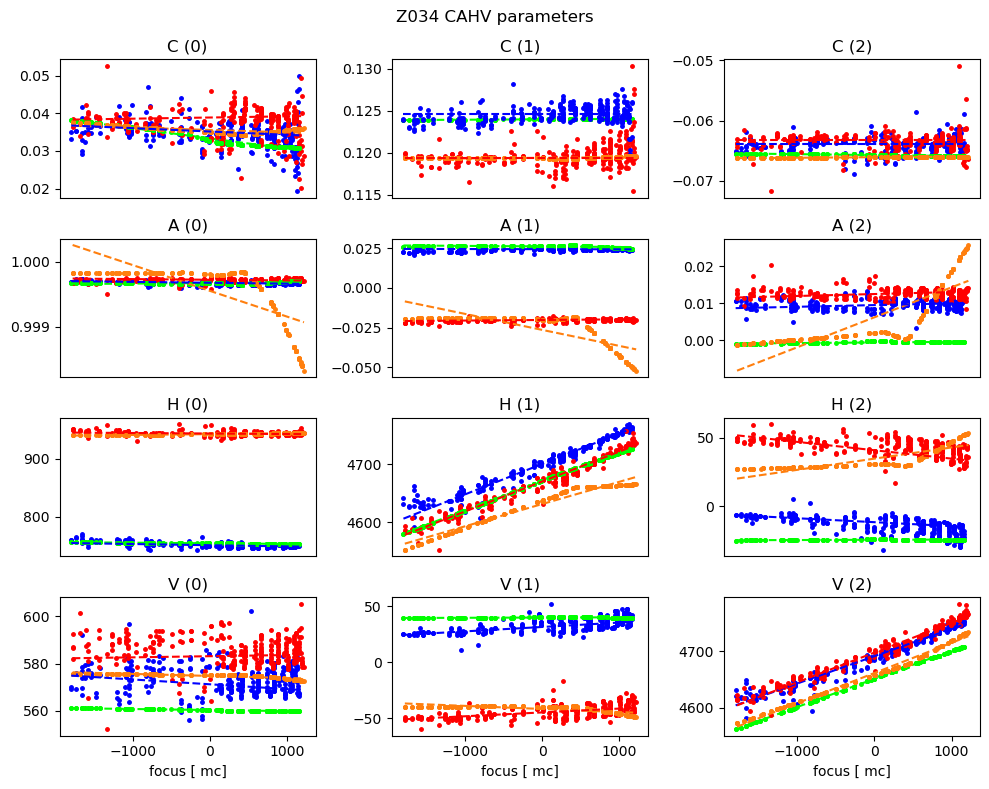

In [ ]:
s = ''
v_names = [ 'Cr0'+s, 'Cr1'+s, 'Cr2'+s, 'Ar0'+s, 'Ar1'+s, 'Ar2'+s, 'Hr0'+s, 'Hr1'+s, 'Hr2'+s, 'Vr0'+s, 'Vr1'+s, 'Vr2'+s, ]
v_sig   = [       1,       0,       0,       1,       1,       1,       1,       1,       1,       1,       1,       1, ]
# v_exc   = [       0,       0,       0,       0,       0,       0,       1,       0,       1,       0,       0,       0, ]


for l in [1]:

    plt.figure( figsize=[10,8])
    plt.suptitle( 'Z'+zooms[l]+ ' CAHV parameters' )

    for z in range(2):

        string = 'Z'+zcams[z]+zooms[l]+'\t '

        df_ = df[ (df['cam'] == 'Z'+zcams[z]+zooms[l])*( df['valid'] == True) ]

        ms = 5
        if l in [0,5]:
            ms = 7
        if l == 6:
            ms = 1
            # df_ = df[ (df['cam'] == 'Z'+zcams[z]+zooms[l])*( df['valid'] == True)*( df['fmc'] > 2000) ]


        x = df_[[ 'fmc' ]].values

        s = ''
        y =     df_[[ 'Cr0'+s, 'Cr1'+s, 'Cr2'+s, 'Ar0'+s, 'Ar1'+s, 'Ar2'+s, 'Hr0'+s, 'Hr1'+s, 'Hr2'+s, 'Vr0'+s, 'Vr1'+s, 'Vr2'+s,  ]].values

        s = '_est'
        y_est = df_[[ 'Cr0'+s, 'Cr1'+s, 'Cr2'+s, 'Ar0'+s, 'Ar1'+s, 'Ar2'+s, 'Hr0'+s, 'Hr1'+s, 'Hr2'+s, 'Vr0'+s, 'Vr1'+s, 'Vr2'+s,  ]].values


        x_min, x_max = [ np.min(x), np.max(x)]
        x_ = np.linspace( x_min, x_max, 2 )

        string += '{:}\t {:}\t '.format(x_min, x_max) 


        

        for v in range(len(v_names)):


            rho, _ = pearsonr( x[:,0], y[:,v])
            if abs(rho) > 0.3:
                a1, a0 = np.polyfit( x[:,0], y[:,v], 1)
            else: 
                a1, a0 = [ 0.0, np.median( y[:,v] )]

            if 0: 

                rho_est, _ = pearsonr( x[:,0], y_est[:,v])
                a1_est, a0_est = np.polyfit( x[:,0], y_est[:,v], 1)

                

            else:

                rho_est = 0.3

                ransac = RANSACRegressor()
                ransac.fit( x, y_est[:,v] )   

                a1_est, a0_est = [ ransac.estimator_.coef_[0], ransac.estimator_.intercept_,  ]


            if abs(rho_est) < 0.3  or ( v_sig[v]==0 ) :
                a1_est, a0_est = [ 0.0, np.median( y_est[:,v] )]

                 

            string += '{:.2f}\t {:.10f}\t {:.10f}\t '.format(rho_est, a1_est, a0_est) 
            
            y_est_ = a0_est + a1_est * x_


            # string += '{:.2f}\t {:}\t {:.10f}\t '.format(rho, a1, a0) 
            
            y_ = a0 + a1 * x_

            plt.subplot(4,3,1+v)
            plt.title( v_names[v][0]+' ('+ v_names[v][2]+')'  )

            if z==0:
                if v==1:
                    plt.plot( x, -y[:,v],     '.', color='lime', zorder=2, ms=ms )
                    plt.plot( x, -y_est[:,v], '.', color='blue', zorder=3, ms=ms )

                    plt.plot( x_,-y_    ,    '--', color='lime', zorder=2 ) 
                    plt.plot( x_,-y_est_,    '--', color='blue', zorder=4 ) 

                else:
                    plt.plot( x, y[:,v],     '.', color='lime', zorder=3, ms=ms )
                    plt.plot( x, y_est[:,v], '.', color='blue', ms=ms )

                    plt.plot( x_,y_    ,    '--', color='lime', zorder=2 ) 
                    plt.plot( x_,y_est_,    '--', color='blue', zorder=4 )
            else:
                plt.plot( x, y[:,v],         '.', color='C1', zorder=3, ms=ms )
                plt.plot( x, y_est[:,v],     '.', color='red',ms=ms )

                plt.plot( x_,y_    ,        '--', color='C1', zorder=3 ) 
                plt.plot( x_,y_est_,        '--', color='red', zorder=4 )

            if v>8:
                plt.xlabel('focus [ mc]')
            else:
                plt.xticks([])

        
        string += '{:.1f}\t {}\t {:.10f}\t '.format( 0.0, np.median(df_['k1']), np.median(df_['k2']) )
        print(string)

    plt.tight_layout()
    # plt.savefig( 'plots/CAHVr_vs_focus_'+zooms[l], dpi=400 )
    


The goal

For a particular state of the Mastcam-Z, find the camera model that best describes it's field behavior.

As state is the zoom k, filter k, focus f, temperature T, pressure P, time of day LMST, etc. at which an image is taken.

The primary metric for the Zcam's "field behavior" is consistency of multi-view stereo projections on natural surfaces and rover hardware. Both are impurtant and valuable for different but complementary reasons. The rover is on Mars to see Mars, not to precisely meet calibration performance expectations. These are merely a means of assureing that science measurments are trustworthy when ground truth is not available. 

The dataset here includes sequences from the first 1000 sols of the Persieverance Rover mission. Although these include dedicated caliration tests, a large fraction of these data were taken for scientific as appose to calirbation purposes. WE leaverage this data because they are inherently more approriate to the missions science goals, more representative of the type of data that needs to have careful validation and error estimation, and becaucause the need to document complex landscapes sometimes requires creative imaging strategies that are more complex than calinration activities and therefore challenge the controls placed on the calibration activities. We therefore include several multi-frame, multispectal science activities. Especially valuable are sequences that capture multiple zoom and focus states on the same landscape. 

The navecames are key to this process because their wide FOVs and greater baselines help control image to image errors.  

In [ ]:
# Fiducials  

# <components next_id="637" active_id="636">
#     <component id="636" label="Component 1">
#       <transform>
#         <rotation locked="true">0.93348050455819431 -0.26865043355832197 0.23757334058918211 0.35809862770816031 0.6622577760156072 -0.65816412158396631 0.01948128443687458 0.69945806354333184 0.7144080744930742</rotation>
#         <translation locked="true">0.37090949138892948 0.82959466930201886 1.9020216895818938</translation>
#         <scale locked="true">0.28729099729582747</scale>
#       </transform>

# Reference

#   <transform>
#         <rotation locked="true">0.93311314994700445 -0.26996210186657699 0.23752960436913811 0.35899085321852203 0.66150471368066732 -0.65843532794322024 0.020625632145871629 0.6996656182306219 0.71417267237310667</rotation>
#         <translation locked="true">0.37170393052954265 0.82932256598229537 1.9023929115653739</translation>
#         <scale locked="true">0.2867301046306866</scale>
#       </transform>


In [ ]:
Rot_fiducials  = np.array([0.93348050455819431, -0.26865043355832197, 0.23757334058918211, 0.35809862770816031, 0.6622577760156072, -0.65816412158396631, 0.01948128443687458, 0.69945806354333184, 0.7144080744930742]).reshape((3,3))
Rot_references = np.array([0.93311314994700445, -0.26996210186657699, 0.23752960436913811, 0.35899085321852203, 0.66150471368066732, -0.65843532794322024, 0.020625632145871629, 0.6996656182306219, 0.71417267237310667]).reshape((3,3))
t_fiducials = np.array([0.37090949138892948, 0.82959466930201886, 1.9020216895818938] )
t_references = np.array([0.37170393052954265, 0.82932256598229537, 1.9023929115653739] )
s_fiducials = 0.2872909972958274
s_references = 0.2867301046306866

-R.from_matrix(Rot_fiducials @ Rot_references.T).as_quat()

array([ 0.00035132, -0.0004781 ,  0.00048555, -0.99999971])

In [ ]:
(Rot_fiducials @ Rot_references.T) @ t_references-t_fiducials

array([ 0.00341888,  0.00070204, -0.00056852])

In [ ]:
s_references/s_fiducials

0.9980476496986669

In [ ]:

# params saved 4/11/24
q_RRp =	 np.array( [   0.00038668, -0.00049777,  0.00131397, -0.99999894 ])
t_RRp =	 np.array( [  -0.00044004,  0.00266759, -0.00182606 ])


# params saved 4/27/24
q_RRp =	 np.array( [   0.00048589, -0.00116867,  0.00121147,  -0.99999847 ])
t_RRp =	 np.array( [   0.00122956,  0.0029741,   0.00080236 ])

# # params saved 4/30/24
# q_RRp 	 [ 0.00014176 -0.00057312  0.00085162 -0.99999946]
# t_RRp 	 [ 0.00053009  0.0009701  -0.00106397]


# params saved 5/31/24
q_RRp =	 np.array( [   0.00035132, -0.0004781 ,  0.00048555, -0.99999971 ])
t_RRp =	 np.array( [   0.0007,  0.003,   0.0006 ])
# s_RRp = 0.998



In [ ]:
      <rotation locked="true">1 0 0 0 1 0 0 0 1</rotation>
        <translation locked="true">0 0 0</translation>
        <scale locked="true">1</scale>